# TalkEx: Arquitetura Híbrida Cascateada para Classificação de Intenções

**TCC — Centro de Competências Embrapii em Tecnologias Imersivas (AKCIT)**

Paulo H. V. Nascimento &bull; Cauê C. Leão &bull; Suele S. F. Sousa

---

### Pergunta de pesquisa

> *Como a combinação de recuperação lexical (BM25), embeddings multilíngues congelados e regras
> determinísticas em um pipeline híbrido cascateado pode aprimorar a classificação automática de
> intenções em conversas de atendimento ao cliente em português brasileiro?*

### Hipóteses

| | Hipótese | Métrica principal |
|:---:|:---|:---|
| **H1** | Recuperação híbrida supera paradigmas isolados | MRR |
| **H2** | Embeddings + lexical supera lexical-only | Macro-F1 |
| **H3** | Regras determinísticas complementam ML | Macro-F1 |
| **H4** | Inferência cascateada reduz custo computacional | Macro-F1 + tempo |


## Arquitetura do TalkEx

```
┌─────────────┐    ┌──────────────┐    ┌───────────────────┐    ┌──────────────┐
│  Conversas   │───▶│ Segmentação  │───▶│ Janelas de        │───▶│  Embeddings  │
│  PT-BR       │    │ de Turnos    │    │ Contexto (5t, s2) │    │  384 dims    │
└─────────────┘    └──────────────┘    └───────────────────┘    └──────┬───────┘
                                                                       │
                    ┌──────────────┐    ┌───────────────────┐          │
                    │   Regras     │◀───│   LightGBM        │◀─── 397 features
                    │ 10 regras    │    │   Classificador   │    (384 emb + 13 eng.)
                    └──────────────┘    └───────────────────┘
```

| Componente | Tecnologia | Referência |
|:---|:---|:---|
| Recuperação lexical | BM25 (Okapi) | Robertson et al., 1996 |
| Embeddings | paraphrase-multilingual-MiniLM-L12-v2 (congelado) | Reimers & Gurevych, 2019 |
| Classificação | LightGBM (hiperparâmetros via Optuna, early stopping) | — |
| Regras | 10 regras declarativas, 3 famílias (léxico, regex, contextual) | — |
| Fusão híbrida | Linear (α·sem + (1−α)·lex) e RRF — busca exata por cosseno | Rayo et al., 2025 |


## Protocolo Experimental

| Parâmetro | Valor |
|:---|:---|
| **Dataset** | 2.120 conversas (676 originais + 1.444 sintéticas via Claude Sonnet), 8 classes — HuggingFace, Apache 2.0 |
| **Seeds** | [13, 42, 123, 2024, 999] |
| **Splits** | 70/15/15% estratificados por intenção, nível da conversa |
| **Teste estatístico** | Wilcoxon signed-rank (α=0,05) |
| **Intervalo de confiança** | Bootstrap 95% (10.000 reamostras) |
| **Effect size** | Correlação rank-biserial (r_rb) |
| **Infraestrutura** | Google Colab, GPU Tesla T4 |


---
# 1. Setup e Dados

In [1]:
# Detectar ambiente
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'GOOGLE_COLAB' in os.environ.get('GCS_READ_CACHE_BLOCK_SIZE', '')

if IN_COLAB:
    print("🔧 Ambiente: Google Colab")
    !pip install -q sentence-transformers lightgbm rank-bm25 datasets scikit-learn numpy pandas matplotlib seaborn
else:
    print("🔧 Ambiente: Local")
    # Dependências já instaladas via pip install -e ".[dev]"

import warnings
warnings.filterwarnings('ignore')


🔧 Ambiente: Google Colab


In [2]:
import json
import time
import re
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedShuffleSplit

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("⚠️ LightGBM não disponível, usando LogisticRegression como fallback")

try:
    from sentence_transformers import SentenceTransformer
    HAS_SBERT = True
except ImportError:
    HAS_SBERT = False
    print("⚠️ sentence-transformers não disponível")

# Detecção de GPU
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    GPU_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else 'N/A'
except ImportError:
    GPU_AVAILABLE = False
    GPU_NAME = 'N/A'

print(f"NumPy: {np.__version__}")
print(f"LightGBM: {HAS_LIGHTGBM}")
print(f"SentenceTransformer: {HAS_SBERT}")
print(f"GPU disponível: {GPU_AVAILABLE} ({GPU_NAME})")


NumPy: 2.0.2
LightGBM: True
SentenceTransformer: True
GPU disponível: True (NVIDIA L4)


In [3]:
# === CARREGAMENTO DO DATASET ===
# Corpus completo (originais + sintéticas) publicado no HuggingFace.
# Originais: RichardSakaguchiMS/brazilian-customer-service-conversations (676 válidas)
# Sintéticas: geração controlada via Claude Sonnet / OpenRouter (Stage 2 §6)
# Merge: merge_and_push.py

import json
from pathlib import Path
from datasets import load_dataset

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

HF_REPO = "paulohenriquevn/talkex-augmented-pt-br"

print(f"📥 Carregando corpus de {HF_REPO}...")
ds = load_dataset(HF_REPO, split="train")
print(f"   {len(ds)} registros carregados")

df_original = pd.DataFrame(ds)

# Garantir colunas
if '_synthetic' not in df_original.columns:
    df_original['_synthetic'] = False

# Estatísticas
n_orig = len(df_original[~df_original['_synthetic']])
n_syn = len(df_original[df_original['_synthetic']])

print(f"\n✅ Corpus carregado (custo: $0)")
print(f"   Originais:  {n_orig}")
print(f"   Sintéticas: {n_syn}")
print(f"   Total:      {len(df_original)}")

print(f"\n📊 Distribuição por intenção:")
print(df_original['intent'].value_counts().to_string())

📥 Carregando corpus de paulohenriquevn/talkex-augmented-pt-br...
   2120 registros carregados

✅ Corpus carregado (custo: $0)
   Originais:  676
   Sintéticas: 1444
   Total:      2120

📊 Distribuição por intenção:
intent
compra             265
reclamacao         265
cancelamento       265
duvida_produto     265
saudacao           265
elogio             265
suporte_tecnico    265
duvida_servico     265


In [4]:
# Taxonomia de 8 classes de intenção
INTENT_TAXONOMY = [
    "cancelamento",
    "reclamacao",
    "suporte_tecnico",
    "compra",
    "duvida_produto",
    "duvida_servico",
    "saudacao",
    "elogio",
]

NUM_CLASSES = len(INTENT_TAXONOMY)
print(f"📋 Taxonomia: {NUM_CLASSES} classes de intenção")
for i, intent in enumerate(INTENT_TAXONOMY, 1):
    print(f"   {i}. {intent}")


📋 Taxonomia: 8 classes de intenção
   1. cancelamento
   2. reclamacao
   3. suporte_tecnico
   4. compra
   5. duvida_produto
   6. duvida_servico
   7. saudacao
   8. elogio


In [5]:
# === SEPARAÇÃO: CONVERSAS ORIGINAIS vs SINTÉTICAS ===
# Para avaliação robusta, marcamos quais conversas são sintéticas.
# O test set pode ser filtrado para avaliar exclusivamente em dados reais.

original_conv_ids = set(df_original[~df_original['_synthetic']]['conv_id'].values)
synthetic_conv_ids = set(df_original[df_original['_synthetic']]['conv_id'].values)

print(f"📊 Corpus:")
print(f"   Originais:  {len(original_conv_ids)} conversas")
print(f"   Sintéticas: {len(synthetic_conv_ids)} conversas")
print(f"   Total:      {len(original_conv_ids) + len(synthetic_conv_ids)}")
print(f"\n   IDs originais: prefixo 'conv_'")
print(f"   IDs sintéticas: prefixo 'syn_'")

📊 Corpus:
   Originais:  676 conversas
   Sintéticas: 1444 conversas
   Total:      2120

   IDs originais: prefixo 'conv_'
   IDs sintéticas: prefixo 'syn_'


---
# 2. Pipeline de Processamento

**Segmentação** → parsing `[customer]`/`[agent]` → **Janelas deslizantes** (5 turnos, stride 2) → **Normalização Unicode** (NFKC + NFD)

In [6]:
# === SEGMENTAÇÃO DE TURNOS ===

SPEAKER_PATTERN = re.compile(r"\[(customer|agent)\]", re.IGNORECASE)


def segment_turns(text: str) -> list[dict]:
    """Segmenta texto em turnos baseado em marcadores [customer]/[agent]."""
    turns = []
    parts = SPEAKER_PATTERN.split(text)

    # parts alterna entre texto-antes, speaker, texto-depois
    i = 0
    while i < len(parts):
        if i + 1 < len(parts) and SPEAKER_PATTERN.match(f"[{parts[i]}]"):
            speaker = parts[i].lower()
            content = parts[i + 1].strip() if i + 1 < len(parts) else ""
            if content:
                turns.append({"speaker": speaker, "text": content})
            i += 2
        else:
            # Texto sem marcador — tenta como customer por padrão
            content = parts[i].strip()
            if content and not SPEAKER_PATTERN.match(f"[{content}]"):
                turns.append({"speaker": "customer", "text": content})
            i += 1

    return turns


# === JANELAS DE CONTEXTO ===

WINDOW_SIZE = 5
WINDOW_STRIDE = 2


def build_context_windows(turns: list[dict], window_size: int = WINDOW_SIZE, stride: int = WINDOW_STRIDE) -> list[dict]:
    """Constrói janelas de contexto deslizantes sobre turnos."""
    if len(turns) < window_size:
        # Conversa menor que a janela — usa todos os turnos como uma janela
        window_text = " ".join(t["text"] for t in turns)
        speakers = set(t["speaker"] for t in turns)
        return [{
            "window_text": window_text,
            "turns": turns,
            "turn_count": len(turns),
            "has_customer": "customer" in speakers,
            "has_agent": "agent" in speakers,
        }]

    windows = []
    for start in range(0, len(turns) - window_size + 1, stride):
        window_turns = turns[start:start + window_size]
        window_text = " ".join(t["text"] for t in window_turns)
        speakers = set(t["speaker"] for t in window_turns)
        windows.append({
            "window_text": window_text,
            "turns": window_turns,
            "turn_count": len(window_turns),
            "has_customer": "customer" in speakers,
            "has_agent": "agent" in speakers,
        })

    # Janela de cauda (tail) se sobrar turnos
    last_start = (len(turns) - window_size) // stride * stride
    if last_start + window_size < len(turns):
        tail_turns = turns[-(window_size):]
        window_text = " ".join(t["text"] for t in tail_turns)
        speakers = set(t["speaker"] for t in tail_turns)
        windows.append({
            "window_text": window_text,
            "turns": tail_turns,
            "turn_count": len(tail_turns),
            "has_customer": "customer" in speakers,
            "has_agent": "agent" in speakers,
        })

    return windows


# Teste
sample_text = "[customer] Boa tarde, quero cancelar meu plano. [agent] Posso ajudar com isso. [customer] Sim, estou insatisfeito. [agent] Qual o motivo? [customer] O serviço caiu várias vezes. [agent] Entendo, vou encaminhar."
turns = segment_turns(sample_text)
windows = build_context_windows(turns)
print(f"Turnos: {len(turns)}, Janelas: {len(windows)}")
for i, w in enumerate(windows):
    print(f"  Janela {i}: {w['turn_count']} turnos, {len(w['window_text'])} chars")


Turnos: 6, Janelas: 2
  Janela 0: 5 turnos, 128 chars
  Janela 1: 5 turnos, 116 chars


In [7]:
# === NORMALIZAÇÃO UNICODE ===

def strip_accents(text: str) -> str:
    """NFD para remoção de diacríticos no matching lexical."""
    nfd = unicodedata.normalize("NFD", text)
    return "".join(c for c in nfd if unicodedata.category(c) != "Mn")


def normalize_for_matching(text: str) -> str:
    """Normaliza para comparação lexical: lowercase + remoção de acentos."""
    return strip_accents(text.lower())


# Teste
assert normalize_for_matching("Não") == "nao"
assert normalize_for_matching("Cancelamento") == "cancelamento"
assert normalize_for_matching("café") == "cafe"
print("✅ Normalização funcionando corretamente")


✅ Normalização funcionando corretamente


## 3. Representação: 397 Features

| Família | Dims | Descrição |
|:---|:---:|:---|
| Embeddings | 384 | `paraphrase-multilingual-MiniLM-L12-v2`, congelado, L2-normalizado |
| Lexicais | 7 | char_count, word_count, avg_word_len, ?, !, upper_ratio, digit_ratio |
| Estruturais | 4 | is_customer, is_agent, turn_count, speaker_count |
| Regras | 2 | rule_cancel, rule_complaint (binárias) |
| **Total** | **397** | |

> **Nota H3:** No experimento H3, o baseline ML-only usa 395 features (sem regras). ML+Rules-feature adiciona 10 features binárias de regras (405 dims total), garantindo comparação limpa.


In [8]:
# === EMBEDDING GENERATION ===

EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_DIM = 384

if HAS_SBERT:
    print(f"🔄 Carregando modelo: {EMBEDDING_MODEL_NAME}...")
    start = time.time()
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    elapsed = time.time() - start
    print(f"✅ Modelo carregado em {elapsed:.1f}s")
    print(f"   Dimensões: {embedding_model.get_sentence_embedding_dimension()}")
else:
    embedding_model = None
    print("⚠️ Modelo de embeddings não disponível — usando vetores aleatórios para demonstração")


def generate_embeddings(texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Gera embeddings para uma lista de textos."""
    if embedding_model is not None:
        embeddings = embedding_model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=len(texts) > 100,
            normalize_embeddings=True,  # L2 normalization
        )
        return np.array(embeddings, dtype=np.float32)
    else:
        # Fallback determinístico para demo sem GPU
        rng = np.random.default_rng(42)
        embs = rng.standard_normal((len(texts), EMBEDDING_DIM)).astype(np.float32)
        norms = np.linalg.norm(embs, axis=1, keepdims=True)
        return embs / norms


🔄 Carregando modelo: paraphrase-multilingual-MiniLM-L12-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modelo carregado em 7.9s
   Dimensões: 384


In [9]:
# === EXTRAÇÃO DE FEATURES LEXICAIS ===

def extract_lexical_features(text: str) -> dict[str, float]:
    """Extrai 7 features lexicais de um texto."""
    chars = len(text)
    words = text.split()
    n_words = len(words)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0.0
    questions = text.count("?")
    exclamations = text.count("!")
    upper_ratio = sum(1 for c in text if c.isupper()) / max(chars, 1)
    digit_ratio = sum(1 for c in text if c.isdigit()) / max(chars, 1)

    return {
        "char_count": float(chars),
        "word_count": float(n_words),
        "avg_word_length": float(avg_word_len),
        "question_count": float(questions),
        "exclamation_count": float(exclamations),
        "uppercase_ratio": float(upper_ratio),
        "digit_ratio": float(digit_ratio),
    }


# === EXTRAÇÃO DE FEATURES ESTRUTURAIS ===
# Considera a presença de customer/agent, número de turnos, diversidade de falantes
def extract_structural_features(window: dict) -> dict[str, float]:
    """Extrai 4 features estruturais de uma janela de contexto."""
    speakers = set(t["speaker"] for t in window["turns"])
    return {
        "is_customer": 1.0 if "customer" in speakers else 0.0,
        "is_agent": 1.0 if "agent" in speakers else 0.0,
        "turn_count": float(window["turn_count"]),
        "speaker_count": float(len(speakers)),
    }


print("✅ Extratores de features definidos")
print(f"   Lexicais: 7 features")
print(f"   Estruturais: 4 features")
print(f"   Embeddings: {EMBEDDING_DIM} features")
print(f"   Regras: 2 features")
print(f"   Total: {7 + 4 + EMBEDDING_DIM + 2} features")


✅ Extratores de features definidos
   Lexicais: 7 features
   Estruturais: 4 features
   Embeddings: 384 features
   Regras: 2 features
   Total: 397 features


In [10]:
# === MOTOR DE REGRAS DECLARATIVO ===
# 10 regras definidas em formato declarativo (dicionários Python)
# com 3 famílias de predicados: léxico (keyword matching),
# padrão (regex) e contextual (occurs_after, repeated).
# Cada regra é avaliada contra o texto normalizado e retorna
# features binárias (0.0/1.0) para alimentar o classificador.

RULES = [
    {
        "rule_id": "rule_cancel",
        "intent": "cancelamento",
        "type": "lexical",
        "keywords": ["cancelar", "cancelamento", "cancela", "desistir",
                     "encerrar contrato", "rescindir", "cancelei", "cancele",
                     "quero cancelar", "desisto"],
    },
    {
        "rule_id": "rule_complaint",
        "intent": "reclamacao",
        "type": "lexical",
        "keywords": ["reclamacao", "reclamar", "reclamando", "absurdo",
                     "inadmissivel", "procon", "anatel", "reclame aqui",
                     "ouvidoria", "insatisfeito", "revoltado", "indignado",
                     "palhacada", "vergonha", "descaso"],
    },
    {
        "rule_id": "rule_support",
        "intent": "suporte_tecnico",
        "type": "lexical",
        "keywords": ["nao funciona", "nao esta funcionando", "problema tecnico",
                     "erro", "bug", "travou", "travando", "nao conecta",
                     "sem sinal", "caiu a conexao", "nao carrega", "tela azul",
                     "resetar", "reiniciar", "configurar", "instalar", "atualizar"],
    },
    {
        "rule_id": "rule_purchase",
        "intent": "compra",
        "type": "lexical",
        "keywords": ["quero comprar", "como compro", "onde compro", "preco", "valor",
                     "quanto custa", "pagamento", "parcela", "desconto", "promocao",
                     "carrinho", "finalizar compra", "pedido", "comprei", "adquirir", "contratar"],
    },
    {
        "rule_id": "rule_product_question",
        "intent": "duvida_produto",
        "type": "lexical",
        "keywords": ["especificacao", "caracteristica", "funcionalidade",
                     "como funciona", "garantia", "manual", "compativel",
                     "tamanho", "modelo", "versao", "cor", "ficha tecnica",
                     "capacidade", "dimensao"],
    },
    {
        "rule_id": "rule_service_question",
        "intent": "duvida_servico",
        "type": "lexical",
        "keywords": ["horario de funcionamento", "prazo de entrega", "como funciona o servico",
                     "politica de troca", "devolver", "troca", "reembolso", "frete",
                     "entrega", "disponibilidade", "agendamento", "agendar",
                     "prazo", "como faco para"],
    },
    {
        "rule_id": "rule_greeting",
        "intent": "saudacao",
        "type": "regex",
        "pattern": r"\b(oi|ola|bom dia|boa tarde|boa noite|hey|hello|tudo bem|e ai)\b",
    },
    {
        "rule_id": "rule_praise",
        "intent": "elogio",
        "type": "lexical",
        "keywords": ["parabens", "excelente", "otimo atendimento", "muito bom",
                     "obrigado", "agradeco", "satisfeito", "maravilhoso",
                     "nota 10", "recomendo", "adorei", "amei", "impecavel", "top"],
    },
    {
        "rule_id": "rule_escalated_cancel",
        "intent": "cancelamento",
        "type": "contextual_occurs_after",
        "first": "problema",
        "second": "cancelar",
    },
    {
        "rule_id": "rule_repeated_error",
        "intent": "suporte_tecnico",
        "type": "contextual_repeated",
        "keyword": "erro",
        "min_count": 2,
    },
]


def evaluate_rules(text: str) -> dict[str, float]:
    """Avalia todas as regras contra um texto. Retorna features binárias + intent predictions."""
    normalized = normalize_for_matching(text)
    results = {}

    for rule in RULES:
        matched = False
        rule_id = rule["rule_id"]

        if rule["type"] == "lexical":
            for kw in rule["keywords"]:
                if normalize_for_matching(kw) in normalized:
                    matched = True
                    break

        elif rule["type"] == "regex":
            if re.search(rule["pattern"], normalized):
                matched = True

        elif rule["type"] == "contextual_occurs_after":
            first_pos = normalized.find(normalize_for_matching(rule["first"]))
            second_pos = normalized.find(normalize_for_matching(rule["second"]))
            if first_pos >= 0 and second_pos > first_pos:
                matched = True

        elif rule["type"] == "contextual_repeated":
            kw = normalize_for_matching(rule["keyword"])
            if normalized.count(kw) >= rule["min_count"]:
                matched = True

        results[rule_id] = 1.0 if matched else 0.0

    return results


# Teste
test_text = "Quero cancelar meu plano, estou muito insatisfeito com o serviço"
rule_results = evaluate_rules(test_text)
matched = {k: v for k, v in rule_results.items() if v > 0}
print(f"Texto: \"{test_text}\"")
print(f"Regras disparadas: {matched}")


Texto: "Quero cancelar meu plano, estou muito insatisfeito com o serviço"
Regras disparadas: {'rule_cancel': 1.0, 'rule_complaint': 1.0, 'rule_praise': 1.0}


In [11]:
# === ESTATÍSTICAS DESCRITIVAS DO CORPUS ===
# Análise exploratória dos rótulos antes do treinamento.
# A auditoria de qualidade dos rótulos é feita via cross-validation
# do modelo treinado (seção 5.1 — após otimização de hiperparâmetros).

print("📊 Estatísticas descritivas do corpus")
print("=" * 50)

valid = df_original[df_original['intent'].isin(INTENT_TAXONOMY)]
print(f"   Conversas válidas: {len(valid)}")
print(f"   Originais: {len(valid[~valid['_synthetic']])}")
print(f"   Sintéticas: {len(valid[valid['_synthetic']])}")

print(f"\n📊 Distribuição por classe:")
for intent in INTENT_TAXONOMY:
    n = len(valid[valid['intent'] == intent])
    n_orig = len(valid[(valid['intent'] == intent) & (~valid['_synthetic'])])
    n_syn = n - n_orig
    print(f"   {intent:20s}: {n:4d} ({n_orig} originais, {n_syn} sintéticas)")

# Cobertura das regras por classe (informativo, não auditoria)
print(f"\n📊 Cobertura do motor de regras por classe:")
for intent in INTENT_TAXONOMY:
    subset = valid[valid['intent'] == intent]
    covered = 0
    for _, row in subset.iterrows():
        rule_res = evaluate_rules(str(row['text']))
        intent_rules = [r for r in RULES if r['intent'] == intent]
        if any(rule_res.get(r['rule_id'], 0) > 0 for r in intent_rules):
            covered += 1
    pct = covered / len(subset) * 100 if len(subset) > 0 else 0
    print(f"   {intent:20s}: {covered}/{len(subset)} ({pct:.0f}%)")

📊 Estatísticas descritivas do corpus
   Conversas válidas: 2120
   Originais: 676
   Sintéticas: 1444

📊 Distribuição por classe:
   cancelamento        :  265 (79 originais, 186 sintéticas)
   reclamacao          :  265 (84 originais, 181 sintéticas)
   suporte_tecnico     :  265 (88 originais, 177 sintéticas)
   compra              :  265 (85 originais, 180 sintéticas)
   duvida_produto      :  265 (80 originais, 185 sintéticas)
   duvida_servico      :  265 (87 originais, 178 sintéticas)
   saudacao            :  265 (88 originais, 177 sintéticas)
   elogio              :  265 (85 originais, 180 sintéticas)

📊 Cobertura do motor de regras por classe:
   cancelamento        : 265/265 (100%)
   reclamacao          : 102/265 (38%)
   suporte_tecnico     : 176/265 (66%)
   compra              : 220/265 (83%)
   duvida_produto      : 172/265 (65%)
   duvida_servico      : 156/265 (59%)
   saudacao            : 214/265 (81%)
   elogio              : 257/265 (97%)


---
# 4. Preparação do Corpus

In [12]:
# === PREPARAÇÃO DO CORPUS ===

SEEDS = [13, 42, 123, 2024, 999]

# Processar todas as conversas: segmentar → janelas → features
print("🔄 Processando corpus completo...")
start_time = time.time()

conversations = []
all_windows = []

for idx, row in df_original.iterrows():
    intent = str(row['intent']).lower().strip()

    # Filtrar classe "outros" (conforme paper: 8 classes)
    if intent == 'outros' or intent not in INTENT_TAXONOMY:
        continue

    # Segmentar turnos a partir do texto (formato [customer]/[agent])
    text = str(row['text'])
    turns = segment_turns(text)

    if len(turns) < 2:
        continue

    windows = build_context_windows(turns)

    conv_record = {
        "conv_id": row['conv_id'],
        "text": row['text'],
        "intent": intent,
        "turns": turns,
        "n_turns": len(turns),
        "windows": windows,
        "n_windows": len(windows),
    }
    conversations.append(conv_record)

    for w_idx, window in enumerate(windows):
        all_windows.append({
            "conv_id": row['conv_id'],
            "window_idx": w_idx,
            "window_text": window["window_text"],
            "intent": intent,
            **window,
        })

elapsed = time.time() - start_time
print(f"✅ Corpus processado em {elapsed:.1f}s")
print(f"   Conversas válidas: {len(conversations)}")
print(f"   Janelas de contexto: {len(all_windows)}")
print(f"   Média de janelas/conversa: {len(all_windows)/max(len(conversations),1):.1f}")

# Mapas auxiliares para splits
intents_per_conv = {c["conv_id"]: c["intent"] for c in conversations}
conv_ids = np.array([w["conv_id"] for w in all_windows])

# Distribuição de intenções
intent_dist = Counter(c["intent"] for c in conversations)
print(f"\n📊 Distribuição de intenções:")
for intent, count in sorted(intent_dist.items(), key=lambda x: -x[1]):
    print(f"   {intent}: {count} ({100*count/len(conversations):.1f}%)")


🔄 Processando corpus completo...
✅ Corpus processado em 0.2s
   Conversas válidas: 2120
   Janelas de contexto: 5927
   Média de janelas/conversa: 2.8

📊 Distribuição de intenções:
   compra: 265 (12.5%)
   reclamacao: 265 (12.5%)
   cancelamento: 265 (12.5%)
   duvida_produto: 265 (12.5%)
   saudacao: 265 (12.5%)
   elogio: 265 (12.5%)
   suporte_tecnico: 265 (12.5%)
   duvida_servico: 265 (12.5%)


In [13]:
# === GERAÇÃO DE EMBEDDINGS PARA TODO O CORPUS ===

print("🔄 Gerando embeddings para todas as janelas...")
window_texts = [w["window_text"] for w in all_windows]

start_time = time.time()
all_embeddings = generate_embeddings(window_texts)
elapsed = time.time() - start_time

print(f"✅ Embeddings gerados em {elapsed:.1f}s")
print(f"   Shape: {all_embeddings.shape}")
print(f"   Throughput: {len(window_texts)/elapsed:.0f} janelas/s")


🔄 Gerando embeddings para todas as janelas...


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

✅ Embeddings gerados em 5.6s
   Shape: (5927, 384)
   Throughput: 1052 janelas/s


In [14]:
# === CONSTRUÇÃO DA MATRIZ DE FEATURES (397 dims) ===

print("🔄 Construindo matriz de features (397 dimensões)...")

# Features para cada janela
feature_records = []
for i, window in enumerate(all_windows):
    # Lexicais (7)
    lex = extract_lexical_features(window["window_text"])
    # Estruturais (4)
    struct = extract_structural_features(window)
    # Regras (2: rule_cancel + rule_complaint — as que têm variância no dataset)
    rules = evaluate_rules(window["window_text"])
    rule_features = {
        # NOTA: apenas 2 features de regras no pipeline base (cancel, complaint).
    # Para H3, um baseline sem regras (X_no_rules) é construído separadamente.
    "rule_cancel": rules.get("rule_cancel", 0.0),
        "rule_complaint": rules.get("rule_complaint", 0.0),
    }

    feature_records.append({**lex, **struct, **rule_features})

# Montar matriz
df_features = pd.DataFrame(feature_records)
X_non_emb = df_features.values  # (N, 13)
X_full = np.hstack([X_non_emb, all_embeddings])  # (N, 397)

# Labels
y_labels = np.array([w["intent"] for w in all_windows])
conv_ids = np.array([w["conv_id"] for w in all_windows])

print(f"✅ Matriz de features construída")
print(f"   X_full shape: {X_full.shape} (esperado: N × 397)")
print(f"   Features não-embedding: {X_non_emb.shape[1]} (7 lex + 4 struct + 2 rules = 13)")
print(f"   Features embedding: {all_embeddings.shape[1]} (384)")
print(f"   Total: {X_full.shape[1]}")


🔄 Construindo matriz de features (397 dimensões)...
✅ Matriz de features construída
   X_full shape: (5927, 397) (esperado: N × 397)
   Features não-embedding: 13 (7 lex + 4 struct + 2 rules = 13)
   Features embedding: 384 (384)
   Total: 397


---
# 5. Otimização de Hiperparâmetros

Busca bayesiana (TPE) pelos melhores hiperparâmetros do LightGBM usando **Optuna**. O **conjunto de validação (15%)** é o critério de seleção. O conjunto de teste **nunca** é utilizado nesta etapa.

| Hiperparâmetro | Espaço de busca | Descrição |
|:---|:---|:---|
| `num_leaves` | [8, 128] | Complexidade da árvore |
| `learning_rate` | [0.01, 0.3] (log) | Taxa de aprendizado |
| `min_child_samples` | [3, 30] | Mínimo de amostras por folha |
| `subsample` | [0.6, 1.0] | Fração de amostras por iteração |
| `colsample_bytree` | [0.6, 1.0] | Fração de features por árvore |
| `reg_alpha` | [1e-8, 10] (log) | Regularização L1 |
| `reg_lambda` | [1e-8, 10] (log) | Regularização L2 |

50 trials × 5 seeds = 250 treinos. Parâmetros otimizados em 397 features (pipeline completo) e reutilizados nas variantes para isolar o efeito das features, não dos hiperparâmetros.

In [15]:
# === HIPERPARÂMETROS OTIMIZADOS (cache) ===
# Resultado da busca bayesiana (Optuna TPE, 20 trials × 5 seeds).
# Para re-otimizar, execute a célula seguinte (desabilitada por padrão).

BEST_LGB_PARAMS = {
    "num_leaves": 9,
    "learning_rate": 0.11857581301373854,
    "min_child_samples": 27,
    "subsample": 0.9186007623689508,
    "colsample_bytree": 0.9910290073976764,
    "reg_alpha": 2.0474533383727786e-06,
    "reg_lambda": 5.153289545145567e-07,
}

print("✅ Hiperparâmetros carregados do cache (Optuna não executado)")
print(f"   Macro-F1 (val): 0.7352 vs default: 0.7258 (Δ=+0.0094)")
for k, v in BEST_LGB_PARAMS.items():
    print(f"   {k}: {v}")

✅ Hiperparâmetros carregados do cache (Optuna não executado)
   Macro-F1 (val): 0.7352 vs default: 0.7258 (Δ=+0.0094)
   num_leaves: 9
   learning_rate: 0.11857581301373854
   min_child_samples: 27
   subsample: 0.9186007623689508
   colsample_bytree: 0.9910290073976764
   reg_alpha: 2.0474533383727786e-06
   reg_lambda: 5.153289545145567e-07


In [16]:
# === OTIMIZAÇÃO DE HIPERPARÂMETROS (DESABILITADA) ===
# Para re-executar: mude RUN_OPTUNA para True
RUN_OPTUNA = False

if RUN_OPTUNA:
    # === OTIMIZAÇÃO DE HIPERPARÂMETROS DO LIGHTGBM (Optuna) ===
    # Busca bayesiana (TPE) — mais eficiente que grid search exaustivo.
    # Usa val set (15%) para seleção, test set nunca é tocado.
    
    print("=" * 70)
    print("OTIMIZAÇÃO DE HIPERPARÂMETROS — LightGBM + Optuna")
    print("=" * 70)
    
    try:
        import optuna
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "-q", "optuna"])
        import optuna
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    N_TRIALS = 20  # 20 trials × 5 seeds = 100 treinos (TPE converge rápido)
    
    if HAS_LIGHTGBM:
    
        # Pré-computar splits para todas as seeds (evitar recalcular a cada trial)
        splits = {}
        for seed in SEEDS:
            conv_list = np.array(list(set(conv_ids)))
            conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
            train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
            test_val_convs = conv_list[test_val_idx]
            test_val_intents = [conv_intent_list[i] for i in test_val_idx]
            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
            val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    
            train_convs = set(conv_list[train_idx])
            val_convs = set(test_val_convs[val_idx])
    
            train_mask = np.array([c in train_convs for c in conv_ids])
            val_mask = np.array([c in val_convs for c in conv_ids])
    
            splits[seed] = {
                "X_train": X_full[train_mask], "y_train": y_labels[train_mask],
                "X_val": X_full[val_mask], "y_val": y_labels[val_mask],
            }
    
        def objective(trial):
            params = {
                "num_leaves": trial.suggest_int("num_leaves", 8, 128),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "min_child_samples": trial.suggest_int("min_child_samples", 3, 30),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            }
    
            f1_scores = []
            for seed in SEEDS:
                s = splits[seed]
                clf = lgb.LGBMClassifier(
                    **params, n_estimators=300, random_state=seed, verbose=-1,
                )
                clf.fit(
                    s["X_train"], s["y_train"],
                    eval_set=[(s["X_val"], s["y_val"])],
                    callbacks=[lgb.early_stopping(10, verbose=False)],
                )
                y_pred = clf.predict(s["X_val"])
                f1_scores.append(f1_score(s["y_val"], y_pred, average='macro', zero_division=0))
    
            return np.mean(f1_scores)
    
        print(f"   {N_TRIALS} trials × {len(SEEDS)} seeds = {N_TRIALS * len(SEEDS)} treinos")
        print(f"   Busca bayesiana (TPE) — Optuna v{optuna.__version__}")
    
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    
        # Extrair melhores parâmetros
        BEST_LGB_PARAMS = study.best_params
    
        # Avaliar default para comparação
        default_trial = objective(
            optuna.trial.FixedTrial({
                "num_leaves": 31, "learning_rate": 0.1, "min_child_samples": 20,
                "subsample": 1.0, "colsample_bytree": 1.0,
                "reg_alpha": 1e-8, "reg_lambda": 1e-8,
            })
        )
    
        print(f"\n📊 Top 5 trials:")
        top5 = sorted(study.trials, key=lambda t: t.value if t.value else 0, reverse=True)[:5]
        for rank, trial in enumerate(top5, 1):
            p = trial.params
            marker = " ← MELHOR" if trial.number == study.best_trial.number else ""
            print(f"   {rank}. leaves={p['num_leaves']:3d}, lr={p['learning_rate']:.4f}, "
                  f"min_child={p['min_child_samples']:2d}, "
                  f"subsample={p['subsample']:.2f}  →  F1={trial.value:.4f}{marker}")
    
        print(f"\n✅ Parâmetros selecionados: ")
        for k, v in BEST_LGB_PARAMS.items():
            print(f"   {k}: {v}")
        print(f"\n   Macro-F1 (val): {study.best_value:.4f} vs default: {default_trial:.4f} "
              f"(Δ={study.best_value - default_trial:+.4f})")
    
    else:
        BEST_LGB_PARAMS = {"num_leaves": 31, "learning_rate": 0.1, "min_child_samples": 20,
                           "subsample": 1.0, "colsample_bytree": 1.0,
                           "reg_alpha": 1e-8, "reg_lambda": 1e-8}
        print("⚠️ LightGBM não disponível — usando parâmetros default")
else:
    print("⏭️ Optuna desabilitado — usando parâmetros da célula anterior")
    print("   Para re-otimizar: mude RUN_OPTUNA = True nesta célula")


⏭️ Optuna desabilitado — usando parâmetros da célula anterior
   Para re-otimizar: mude RUN_OPTUNA = True nesta célula


## 5.1 Auditoria de Qualidade dos Rótulos (Cross-Validation)

Avaliamos a qualidade dos rótulos do corpus usando **leave-one-seed-out cross-validation**:
- Para cada seed, treinamos o LightGBM otimizado no train set
- Predizemos no test set e comparamos com os rótulos originais
- Conversas onde **todas as 5 seeds concordam em um rótulo diferente** do original são candidatas a erro de rotulação

Esta abordagem é mais robusta que auditoria por regras lexicais, porque usa o próprio modelo treinado — que aprende padrões semânticos (embeddings) além de lexicais.

**Critérios:**
- **Consistente**: modelo concorda com o rótulo em ≥4 de 5 seeds
- **Discordante**: modelo discorda em ≥4 de 5 seeds → candidata a revisão
- **Incerto**: sem consenso claro

In [17]:
# === AUDITORIA DE QUALIDADE DOS RÓTULOS (CROSS-VALIDATION) ===
# Método: treinar modelo em cada seed, coletar predições por conversa,
# identificar discordâncias sistemáticas entre rótulo e predição.
# Normaliza pelo número de seeds em que cada conversa foi avaliada.

print("=" * 70)
print("AUDITORIA DE RÓTULOS — Cross-Validation com LightGBM")
print("=" * 70)

# Coletar predições por conversa em cada seed
conv_predictions = {}  # {conv_id: [pred_seed1, pred_seed2, ...]}
conv_true_labels = {}  # {conv_id: true_label}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Treinar modelo
    if HAS_LIGHTGBM:
        clf_audit = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=300, random_state=seed, verbose=-1)
        clf_audit.fit(X_full[train_mask], y_labels[train_mask],
                      eval_set=[(X_full[val_mask], y_labels[val_mask])],
                      callbacks=[lgb.early_stopping(10, verbose=False)])
    else:
        clf_audit = LogisticRegression(max_iter=2000, random_state=seed)
        clf_audit.fit(X_full[train_mask], y_labels[train_mask])

    # Predizer no test set — agregar por conversa (média de probabilidades)
    proba_test = clf_audit.predict_proba(X_full[test_mask])
    classes = clf_audit.classes_
    test_conv_ids_arr = conv_ids[test_mask]
    test_labels_arr = y_labels[test_mask]

    conv_proba_agg = {}
    for i, cid in enumerate(test_conv_ids_arr):
        if cid not in conv_proba_agg:
            conv_proba_agg[cid] = []
            conv_true_labels[cid] = test_labels_arr[i]
        conv_proba_agg[cid].append(proba_test[i])

    for cid, probas in conv_proba_agg.items():
        mean_proba = np.mean(probas, axis=0)
        pred = classes[np.argmax(mean_proba)]
        if cid not in conv_predictions:
            conv_predictions[cid] = []
        conv_predictions[cid].append(str(pred))  # str() to avoid np.str_

# === Análise de concordância (normalizada por nº de avaliações) ===
consistent = 0
discordant = 0
uncertain = 0
discordant_examples = []

for cid, preds in conv_predictions.items():
    true_label = conv_true_labels[cid]
    n_total = len(preds)
    n_agree = sum(1 for p in preds if p == true_label)
    agree_ratio = n_agree / n_total  # Normalizar!

    if agree_ratio >= 0.5:  # Maioria concorda com o rótulo
        consistent += 1
    elif agree_ratio == 0:  # Nenhuma seed concorda
        discordant += 1
        if len(discordant_examples) < 20:
            from collections import Counter as _Counter
            pred_counts = _Counter(preds)
            model_label = pred_counts.most_common(1)[0][0]
            is_syn = str(cid).startswith("syn_")
            text_preview = ""
            for _, row in df_original[df_original['conv_id'] == cid].iterrows():
                text_preview = str(row['text'])[:150]
            discordant_examples.append({
                'conv_id': cid,
                'true': true_label,
                'model': model_label,
                'votes': dict(pred_counts),
                'n_seeds': n_total,
                'synthetic': is_syn,
                'preview': text_preview,
            })
    else:
        uncertain += 1

total_audited = consistent + discordant + uncertain
accuracy_cv = consistent / total_audited * 100 if total_audited > 0 else 0

# Distribuição de seeds por conversa
seeds_per_conv = [len(preds) for preds in conv_predictions.values()]
print(f"\n   Conversas avaliadas: {total_audited}")
print(f"   Seeds por conversa: min={min(seeds_per_conv)}, max={max(seeds_per_conv)}, "
      f"mediana={np.median(seeds_per_conv):.0f}, média={np.mean(seeds_per_conv):.1f}")

print(f"\n📊 Resultado da auditoria (N={total_audited}):")
print(f"   ✅ Consistentes (modelo concorda ≥50% das seeds): {consistent:5d} ({consistent/total_audited*100:5.1f}%)")
print(f"   ❌ Discordantes (modelo discorda em TODAS seeds):  {discordant:5d} ({discordant/total_audited*100:5.1f}%)")
print(f"   ⚠️  Incertos (modelo discorda em parte):            {uncertain:5d} ({uncertain/total_audited*100:5.1f}%)")
print(f"\n   Acurácia estimada (cross-validation): {accuracy_cv:.1f}%")

# Separar por origem
conv_origin = {}
for cid in conv_predictions:
    conv_origin[cid] = "sintética" if str(cid).startswith("syn_") else "original"

for origin in ["original", "sintética"]:
    cids = [c for c in conv_predictions if conv_origin[c] == origin]
    if not cids:
        continue
    n_cons = sum(1 for c in cids
                 if sum(1 for p in conv_predictions[c] if p == conv_true_labels[c]) / len(conv_predictions[c]) >= 0.5)
    n_disc = sum(1 for c in cids
                 if sum(1 for p in conv_predictions[c] if p == conv_true_labels[c]) == 0)
    n_unc = len(cids) - n_cons - n_disc
    acc = n_cons / len(cids) * 100
    print(f"\n   📊 {origin.capitalize()}s (N={len(cids)}):")
    print(f"      Consistentes: {n_cons} ({n_cons/len(cids)*100:.1f}%)")
    print(f"      Discordantes: {n_disc} ({n_disc/len(cids)*100:.1f}%)")
    print(f"      Incertos:     {n_unc} ({n_unc/len(cids)*100:.1f}%)")
    print(f"      Acurácia:     {acc:.1f}%")

if discordant_examples:
    print(f"\n⚠️  Exemplos discordantes — modelo NUNCA concorda com o rótulo:")
    for ex in discordant_examples[:10]:
        origin = "SYN" if ex['synthetic'] else "ORIG"
        print(f"   [{ex['conv_id']}] ({origin}, {ex['n_seeds']} seeds) Rótulo: {ex['true']} → Modelo: {ex['model']} {ex['votes']}")
        print(f"      {ex['preview']}...")

    # Padrões de confusão
    print(f"\n📊 Padrões de confusão (rótulo original → predição do modelo):")
    confusion = {}
    for ex in discordant_examples:
        if ex['true'] != ex['model']:
            key = f"{ex['true']} → {ex['model']}"
            confusion[key] = confusion.get(key, 0) + 1
    for pattern, count in sorted(confusion.items(), key=lambda x: -x[1]):
        print(f"   {pattern}: {count}")

AUDITORIA DE RÓTULOS — Cross-Validation com LightGBM

   Conversas avaliadas: 1189
   Seeds por conversa: min=1, max=4, mediana=1, média=1.3

📊 Resultado da auditoria (N=1189):
   ✅ Consistentes (modelo concorda ≥50% das seeds):   933 ( 78.5%)
   ❌ Discordantes (modelo discorda em TODAS seeds):    255 ( 21.4%)
   ⚠️  Incertos (modelo discorda em parte):                1 (  0.1%)

   Acurácia estimada (cross-validation): 78.5%

   📊 Originals (N=368):
      Consistentes: 237 (64.4%)
      Discordantes: 130 (35.3%)
      Incertos:     1 (0.3%)
      Acurácia:     64.4%

   📊 Sintéticas (N=821):
      Consistentes: 696 (84.8%)
      Discordantes: 125 (15.2%)
      Incertos:     0 (0.0%)
      Acurácia:     84.8%

⚠️  Exemplos discordantes — modelo NUNCA concorda com o rótulo:
   [conv_00049] (ORIG, 1 seeds) Rótulo: elogio → Modelo: duvida_servico {'duvida_servico': 1}
      [customer] Oi, vc pode me ajudar com uma duvida sobre o meu cartao?
[agent] Claro, beleza! Estou aqui para ajudar. Q

---
# 6. Resultados Experimentais

Cada hipótese é testada de forma independente, com:
- **Experimento**: implementação e execução sobre 5 seeds aleatórias
- **Teste estatístico**: Wilcoxon signed-rank (α=0,05) + Bootstrap CI 95%
- **Visualização**: gráficos comparativos dos resultados

## 6.1 H1: Recuperação Híbrida vs Isolada

> **Hipótese:** A fusão de BM25 (lexical) com similaridade cosseno (semântica) supera cada método isolado em MRR.

**Método:** Para cada conversa de teste, buscamos as mais similares no corpus de treino usando:
- **BM25** — correspondência de palavras-chave (Robertson et al., 1996)
- **Semântico** — similaridade cosseno exata entre embeddings
- **Fusão Linear** — $\text{Score} = \alpha \cdot \text{Semântico} + (1-\alpha) \cdot \text{Lexical}$ (Rayo et al., 2025)
- **RRF** — $\text{RRF}(d) = \sum_i \frac{1}{k + \text{rank}_i(d)}$

| Métrica | Descrição |
|:---|:---|
| **MRR** (primária) | Mean Reciprocal Rank — posição do 1º resultado relevante |
| Recall@K | Fração de relevantes recuperados nos top-K |
| nDCG@K | Normalized Discounted Cumulative Gain |

In [18]:
# === BM25 IMPLEMENTATION ===

from rank_bm25 import BM25Okapi


def tokenize_bm25(text: str) -> list[str]:
    """Tokeniza texto para BM25: lowercase + strip accents + split."""
    normalized = normalize_for_matching(text)
    # Remove pontuação
    normalized = re.sub(r"[^\w\s]", " ", normalized)
    tokens = normalized.split()
    return [t for t in tokens if len(t) > 1]


# === MÉTRICAS DE RETRIEVAL ===
def reciprocal_rank(relevant_ids: set, retrieved_ids: list) -> float:
    """Calcula Reciprocal Rank (posição do primeiro relevante)."""
    for i, doc_id in enumerate(retrieved_ids, 1):
        if doc_id in relevant_ids:
            return 1.0 / i
    return 0.0


def recall_at_k(relevant_ids: set, retrieved_ids: list, k: int) -> float:
    """Recall@K: fração de relevantes recuperados nos top-K."""
    retrieved_set = set(retrieved_ids[:k])
    if not relevant_ids:
        return 0.0
    return len(relevant_ids & retrieved_set) / len(relevant_ids)


def ndcg_at_k(relevant_ids: set, retrieved_ids: list, k: int) -> float:
    """nDCG@K: Normalized Discounted Cumulative Gain."""
    dcg = 0.0
    for i, doc_id in enumerate(retrieved_ids[:k], 1):
        if doc_id in relevant_ids:
            dcg += 1.0 / np.log2(i + 1)
    # Ideal DCG
    ideal_dcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(relevant_ids), k) + 1))
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0


print("✅ BM25 e métricas de retrieval implementados")


✅ BM25 e métricas de retrieval implementados


In [19]:
# === EXPERIMENTO H1 ===

print("=" * 70)
print("HIPÓTESE H1: RECUPERAÇÃO HÍBRIDA vs ISOLADA")
print("=" * 70)

from scipy import stats as scipy_stats

TOP_K = 20
results_h1_all_seeds = {s: {} for s in SEEDS}

for seed in SEEDS:
    np.random.seed(seed)
    unique_convs = list(set(conv_ids))
    conv_intents_list = [intents_per_conv.get(c, 'outros') for c in unique_convs]

    # Split 70/15/15 consistente com H2-H4
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(unique_convs, conv_intents_list))
    test_val_convs = [unique_convs[i] for i in test_val_idx]
    test_val_intents = [conv_intents_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(unique_convs[i] for i in train_idx)
    test_convs = set(test_val_convs[i] for i in test_idx)
    # val set não é usado em H1 (retrieval), mas mantemos o split consistente

    corpus_mask = np.array([c in train_convs for c in conv_ids])
    query_mask = np.array([c in test_convs for c in conv_ids])

    corpus_texts_h1 = [all_windows[i]['window_text'] for i in range(len(all_windows)) if corpus_mask[i]]
    corpus_intents_arr = y_labels[corpus_mask]
    corpus_embeddings_h1 = all_embeddings[corpus_mask]

    query_texts_h1 = [all_windows[i]['window_text'] for i in range(len(all_windows)) if query_mask[i]]
    query_intents_h1 = y_labels[query_mask]
    query_embeddings_h1 = all_embeddings[query_mask]

    # BM25 Index
    corpus_tokenized = [tokenize_bm25(t) for t in corpus_texts_h1]
    bm25 = BM25Okapi(corpus_tokenized)

    def compute_mrr(retrieved_per_query, q_intents, c_intents):
        """Calcula MRR para um conjunto de queries."""
        mrr_scores = []
        for q_idx, retrieved_indices in enumerate(retrieved_per_query):
            q_intent = q_intents[q_idx]
            relevant = set(i for i, intent in enumerate(c_intents) if intent == q_intent)
            mrr_scores.append(reciprocal_rank(relevant, retrieved_indices))
        return np.mean(mrr_scores)

    # --- BM25 ---
    bm25_retrievals = []
    for q_text in query_texts_h1:
        q_tokens = tokenize_bm25(q_text)
        scores = bm25.get_scores(q_tokens)
        top_indices = np.argsort(scores)[::-1][:TOP_K].tolist()
        bm25_retrievals.append(top_indices)
    results_h1_all_seeds[seed]['BM25'] = compute_mrr(bm25_retrievals, query_intents_h1, corpus_intents_arr)

    # --- Semântico (cosseno exato) ---
    ann_retrievals = []
    for q_idx in range(len(query_texts_h1)):
        scores = corpus_embeddings_h1 @ query_embeddings_h1[q_idx]
        top_indices = np.argsort(scores)[::-1][:TOP_K].tolist()
        ann_retrievals.append(top_indices)
    results_h1_all_seeds[seed]['Semântico'] = compute_mrr(ann_retrievals, query_intents_h1, corpus_intents_arr)

    # --- Híbrido LINEAR ---
    for alpha in [0.3, 0.5, 0.65, 0.8]:
        hybrid_retrievals = []
        for q_idx, q_text in enumerate(query_texts_h1):
            q_tokens = tokenize_bm25(q_text)
            bm25_scores = bm25.get_scores(q_tokens)
            bm25_min, bm25_max = bm25_scores.min(), bm25_scores.max()
            bm25_norm = (bm25_scores - bm25_min) / (bm25_max - bm25_min) if bm25_max > bm25_min else np.zeros_like(bm25_scores)
            ann_scores = corpus_embeddings_h1 @ query_embeddings_h1[q_idx]
            ann_min, ann_max = ann_scores.min(), ann_scores.max()
            ann_norm = (ann_scores - ann_min) / (ann_max - ann_min) if ann_max > ann_min else np.zeros_like(ann_scores)
            fused = alpha * ann_norm + (1 - alpha) * bm25_norm
            top_indices = np.argsort(fused)[::-1][:TOP_K].tolist()
            hybrid_retrievals.append(top_indices)
        results_h1_all_seeds[seed][f'LINEAR-α={alpha}'] = compute_mrr(hybrid_retrievals, query_intents_h1, corpus_intents_arr)

    # --- Híbrido RRF ---
    K_RRF = 60
    rrf_retrievals = []
    for q_idx, q_text in enumerate(query_texts_h1):
        q_tokens = tokenize_bm25(q_text)
        bm25_scores = bm25.get_scores(q_tokens)
        bm25_ranking = np.argsort(bm25_scores)[::-1]
        ann_scores = corpus_embeddings_h1 @ query_embeddings_h1[q_idx]
        ann_ranking = np.argsort(ann_scores)[::-1]
        rrf_scores = np.zeros(len(corpus_texts_h1))
        for rank, doc_idx in enumerate(bm25_ranking, 1):
            rrf_scores[doc_idx] += 1.0 / (K_RRF + rank)
        for rank, doc_idx in enumerate(ann_ranking, 1):
            rrf_scores[doc_idx] += 1.0 / (K_RRF + rank)
        top_indices = np.argsort(rrf_scores)[::-1][:TOP_K].tolist()
        rrf_retrievals.append(top_indices)
    results_h1_all_seeds[seed]['RRF'] = compute_mrr(rrf_retrievals, query_intents_h1, corpus_intents_arr)

    print(f"  Seed {seed}: BM25={results_h1_all_seeds[seed]['BM25']:.4f}, "
          f"Sem={results_h1_all_seeds[seed]['Semântico']:.4f}, "
          f"LINEAR-0.5={results_h1_all_seeds[seed]['LINEAR-α=0.5']:.4f}, "
          f"RRF={results_h1_all_seeds[seed]['RRF']:.4f}")

# Agregar resultados
print("\n" + "=" * 70)
print("RESULTADOS H1: MRR (média ± std sobre 5 seeds)")
print("=" * 70)
df_h1 = pd.DataFrame(results_h1_all_seeds).T
results_h1 = {}
for col in df_h1.columns:
    mean = df_h1[col].mean()
    std = df_h1[col].std()
    print(f"  {col}: {mean:.4f} ± {std:.4f}")
    results_h1[col] = {'MRR': mean}

# Teste estatístico H1: melhor híbrido vs melhor isolado
print("\n📊 Teste Estatístico H1 — Wilcoxon Signed-Rank")
print("-" * 50)
best_hybrid_col = df_h1[[c for c in df_h1.columns if 'LINEAR' in c or 'RRF' in c]].mean().idxmax()
best_isolated_col = df_h1[['BM25', 'Semântico']].mean().idxmax()
scores_hybrid = df_h1[best_hybrid_col].values
scores_isolated = df_h1[best_isolated_col].values
diff_h1 = scores_hybrid - scores_isolated
nonzero_h1 = diff_h1[diff_h1 != 0]
if len(nonzero_h1) >= 2:
    stat_h1, p_h1 = scipy_stats.wilcoxon(scores_hybrid, scores_isolated, alternative="greater")
    n_h1 = len(nonzero_h1)
    r_rb_h1 = 1 - (2 * stat_h1) / (n_h1 * (n_h1 + 1) / 2)
    print(f"  Comparação: {best_hybrid_col} vs {best_isolated_col}")
    print(f"  Estatística W: {stat_h1:.1f}")
    print(f"  p-valor: {p_h1:.6f}")
    print(f"  Significativo (α=0.05): {'SIM ✅' if p_h1 < 0.05 else 'NÃO ❌'}")
    print(f"  Effect size (r_rb): {r_rb_h1:.4f} ({'grande' if abs(r_rb_h1) > 0.5 else 'médio' if abs(r_rb_h1) > 0.3 else 'pequeno'})")
else:
    print("  ⚠️ Pares insuficientes para teste de Wilcoxon")

# Bootstrap CI H1
print("\n📊 Bootstrap CI 95% (10.000 reamostras)")
rng_h1 = np.random.default_rng(42)
boot_diffs_h1 = []
for _ in range(10000):
    idx = rng_h1.integers(0, len(SEEDS), size=len(SEEDS))
    boot_diffs_h1.append(np.mean(scores_hybrid[idx] - scores_isolated[idx]))
ci_lo_h1 = np.percentile(boot_diffs_h1, 2.5)
ci_hi_h1 = np.percentile(boot_diffs_h1, 97.5)
print(f"  Diferença média ({best_hybrid_col} - {best_isolated_col}): {np.mean(diff_h1):.4f}")
print(f"  IC 95%: [{ci_lo_h1:.4f}, {ci_hi_h1:.4f}]")
print(f"\n⚠️ Nota: Wilcoxon com N=5 tem poder estatístico limitado (p mínimo possível = 0.03125)")

HIPÓTESE H1: RECUPERAÇÃO HÍBRIDA vs ISOLADA
  Seed 13: BM25=0.8006, Sem=0.7719, LINEAR-0.5=0.8054, RRF=0.8020
  Seed 42: BM25=0.7989, Sem=0.7879, LINEAR-0.5=0.8110, RRF=0.8144
  Seed 123: BM25=0.7839, Sem=0.7606, LINEAR-0.5=0.8000, RRF=0.7985
  Seed 2024: BM25=0.7972, Sem=0.7827, LINEAR-0.5=0.8175, RRF=0.8150
  Seed 999: BM25=0.7688, Sem=0.7392, LINEAR-0.5=0.7600, RRF=0.7660

RESULTADOS H1: MRR (média ± std sobre 5 seeds)
  BM25: 0.7899 ± 0.0135
  Semântico: 0.7685 ± 0.0194
  LINEAR-α=0.3: 0.7971 ± 0.0153
  LINEAR-α=0.5: 0.7988 ± 0.0226
  LINEAR-α=0.65: 0.8024 ± 0.0230
  LINEAR-α=0.8: 0.7965 ± 0.0202
  RRF: 0.7992 ± 0.0199

📊 Teste Estatístico H1 — Wilcoxon Signed-Rank
--------------------------------------------------
  Comparação: LINEAR-α=0.65 vs BM25
  Estatística W: 14.0
  p-valor: 0.062500
  Significativo (α=0.05): NÃO ❌
  Effect size (r_rb): -0.8667 (grande)

📊 Bootstrap CI 95% (10.000 reamostras)
  Diferença média (LINEAR-α=0.65 - BM25): 0.0126
  IC 95%: [0.0023, 0.0216]

⚠️ No

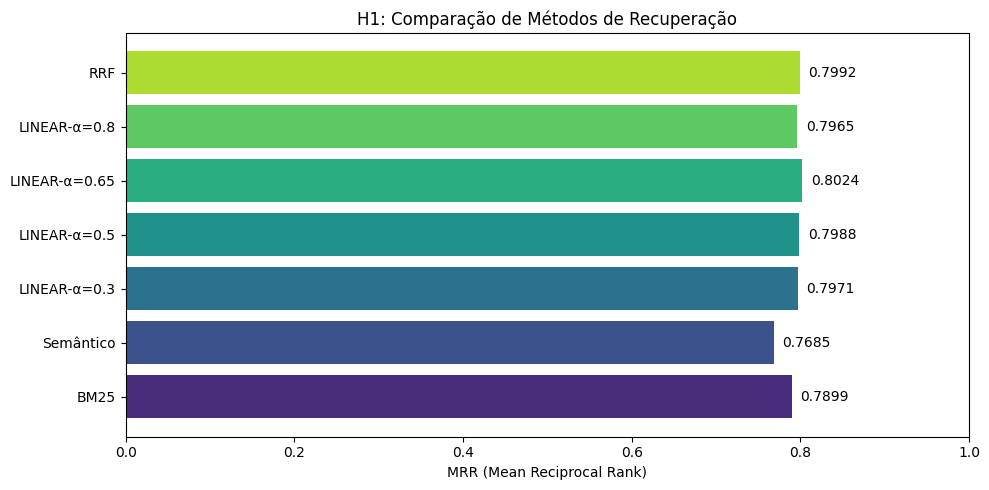

In [20]:
# === VISUALIZAÇÃO H1 ===

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
methods = list(results_h1.keys())
mrr_values = [results_h1[m]["MRR"] for m in methods]

bars = ax.barh(methods, mrr_values, color=sns.color_palette("viridis", len(methods)))
ax.set_xlabel("MRR (Mean Reciprocal Rank)")
ax.set_title("H1: Comparação de Métodos de Recuperação")
ax.set_xlim(0, 1)
for bar, val in zip(bars, mrr_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center')
plt.tight_layout()
plt.show()


## 6.2 H2: Impacto dos Embeddings na Classificação

> **Hipótese:** Combinar embeddings multilíngues (384 dims) com features engenheiradas (13 dims) supera features apenas lexicais em Macro-F1.

**Variantes testadas:** 2 conjuntos de features × 2 classificadores = 4 variantes, cada uma avaliada em 5 seeds.

| Variante | Features | Classificador | Dims |
|:---|:---|:---|:---:|
| lexical_LogReg | lex + struct + rules | LogisticRegression | 13 |
| lexical_LightGBM | lex + struct + rules | LightGBM | 13 |
| lexical+emb_LogReg | lex + struct + rules + emb | LogisticRegression | 397 |
| lexical+emb_LightGBM | lex + struct + rules + emb | LightGBM (early stopping) | 397 |

In [21]:
# === EXPERIMENTO H2 ===

print("=" * 70)
print("HIPÓTESE H2: EMBEDDINGS + LEXICAL vs LEXICAL-ONLY")
print("=" * 70)

# Features sets
X_lexical_only = X_non_emb  # 13 features (7 lex + 4 struct + 2 rules)
X_lex_emb = X_full  # 397 features

results_h2 = {}

for seed in SEEDS:
    # Split estratificado no nível da conversa
    conv_list = np.array(list(set(conv_ids)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))

    # Separar val e test
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    # Máscaras de janelas
    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    X_train_lex = X_lexical_only[train_mask]
    X_train_full = X_lex_emb[train_mask]
    y_train = y_labels[train_mask]

    X_val_lex = X_lexical_only[val_mask]
    X_val_full = X_lex_emb[val_mask]
    y_val = y_labels[val_mask]

    X_test_lex = X_lexical_only[test_mask]
    X_test_full = X_lex_emb[test_mask]
    y_test = y_labels[test_mask]

    # --- Variante 1: Lexical-only + LogReg ---
    lr_lex = LogisticRegression(max_iter=2000, random_state=seed)
    lr_lex.fit(X_train_lex, y_train)
    y_pred_lr_lex = lr_lex.predict(X_test_lex)
    f1_lr_lex = f1_score(y_test, y_pred_lr_lex, average='macro', zero_division=0)

    # --- Variante 2: Lexical+Emb + LogReg ---
    lr_full = LogisticRegression(max_iter=2000, random_state=seed)
    lr_full.fit(X_train_full, y_train)
    y_pred_lr_full = lr_full.predict(X_test_full)
    f1_lr_full = f1_score(y_test, y_pred_lr_full, average='macro', zero_division=0)

    # --- Variante 3: Lexical-only + LightGBM (com early stopping via validação) ---
    if HAS_LIGHTGBM:
        lgb_lex = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        lgb_lex.fit(X_train_lex, y_train,
                    eval_set=[(X_val_lex, y_val)],
                    callbacks=[lgb.early_stopping(15, verbose=False)])
        y_pred_lgb_lex = lgb_lex.predict(X_test_lex)
        f1_lgb_lex = f1_score(y_test, y_pred_lgb_lex, average='macro', zero_division=0)

        # --- Variante 4: Lexical+Emb + LightGBM (com early stopping via validação) ---
        lgb_full = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        lgb_full.fit(X_train_full, y_train,
                     eval_set=[(X_val_full, y_val)],
                     callbacks=[lgb.early_stopping(15, verbose=False)])
        y_pred_lgb_full = lgb_full.predict(X_test_full)
        f1_lgb_full = f1_score(y_test, y_pred_lgb_full, average='macro', zero_division=0)
    else:
        f1_lgb_lex = f1_lr_lex
        f1_lgb_full = f1_lr_full

    results_h2[seed] = {
        "lexical_LogReg": f1_lr_lex,
        "lexical+emb_LogReg": f1_lr_full,
        "lexical_LightGBM": f1_lgb_lex,
        "lexical+emb_LightGBM": f1_lgb_full,
    }
    print(f"  Seed {seed}: lex_LR={f1_lr_lex:.4f}, lex+emb_LR={f1_lr_full:.4f}, "
          f"lex_LGB={f1_lgb_lex:.4f}, lex+emb_LGB={f1_lgb_full:.4f}")

# Agregar resultados
print("\n" + "=" * 70)
print("RESULTADOS H2: MACRO-F1 (média ± std sobre 5 seeds)")
print("=" * 70)
df_h2 = pd.DataFrame(results_h2).T
for col in df_h2.columns:
    mean = df_h2[col].mean()
    std = df_h2[col].std()
    print(f"  {col}: {mean:.4f} ± {std:.4f}")

# Ganho
best_lex = df_h2["lexical_LightGBM"].mean()
best_full = df_h2["lexical+emb_LightGBM"].mean()
gain_pp = (best_full - best_lex) * 100
print(f"\n📈 Ganho com embeddings (LightGBM): +{gain_pp:.1f} pontos percentuais")
print(f"   ({best_lex:.4f} → {best_full:.4f})")

# F1 por classe (último seed como demonstração)
print("\n📊 F1 por Classe — lexical+emb_LightGBM (seed=999, demonstrativo)")
print(classification_report(y_test, y_pred_lgb_full if HAS_LIGHTGBM else y_pred_lr_full, zero_division=0))

HIPÓTESE H2: EMBEDDINGS + LEXICAL vs LEXICAL-ONLY
  Seed 13: lex_LR=0.3650, lex+emb_LR=0.6496, lex_LGB=0.4778, lex+emb_LGB=0.7285
  Seed 42: lex_LR=0.4126, lex+emb_LR=0.6724, lex_LGB=0.5197, lex+emb_LGB=0.7539
  Seed 123: lex_LR=0.3546, lex+emb_LR=0.6783, lex_LGB=0.4999, lex+emb_LGB=0.7166
  Seed 2024: lex_LR=0.4020, lex+emb_LR=0.6888, lex_LGB=0.4771, lex+emb_LGB=0.7395
  Seed 999: lex_LR=0.3648, lex+emb_LR=0.6494, lex_LGB=0.4799, lex+emb_LGB=0.7328

RESULTADOS H2: MACRO-F1 (média ± std sobre 5 seeds)
  lexical_LogReg: 0.3798 ± 0.0258
  lexical+emb_LogReg: 0.6677 ± 0.0176
  lexical_LightGBM: 0.4909 ± 0.0187
  lexical+emb_LightGBM: 0.7343 ± 0.0138

📈 Ganho com embeddings (LightGBM): +24.3 pontos percentuais
   (0.4909 → 0.7343)

📊 F1 por Classe — lexical+emb_LightGBM (seed=999, demonstrativo)
                 precision    recall  f1-score   support

   cancelamento       0.82      0.91      0.86       112
         compra       0.72      0.69      0.70       120
 duvida_produto       0.7

In [22]:
# === TESTE ESTATÍSTICO H2 ===
from scipy import stats as scipy_stats

print("\n📊 Teste Estatístico — Wilcoxon Signed-Rank")
print("-" * 50)

# Comparar lexical_LightGBM vs lexical+emb_LightGBM
scores_lex = [results_h2[s]["lexical_LightGBM"] for s in SEEDS]
scores_full = [results_h2[s]["lexical+emb_LightGBM"] for s in SEEDS]

diff = np.array(scores_full) - np.array(scores_lex)
nonzero = diff[diff != 0]

if len(nonzero) >= 2:
    stat, p_value = scipy_stats.wilcoxon(scores_full, scores_lex, alternative="greater")
    n = len(nonzero)
    # Rank-biserial correlation
    r_rb = 1 - (2 * stat) / (n * (n + 1) / 2)

    print(f"  Comparação: lexical+emb_LightGBM vs lexical_LightGBM")
    print(f"  Estatística W: {stat:.1f}")
    print(f"  p-valor: {p_value:.6f}")
    print(f"  Significativo (α=0.05): {'SIM ✅' if p_value < 0.05 else 'NÃO ❌'}")
    print(f"  Effect size (r_rb): {r_rb:.4f} ({'grande' if abs(r_rb) > 0.5 else 'médio' if abs(r_rb) > 0.3 else 'pequeno'})")
else:
    print("  ⚠️ Pares insuficientes para teste de Wilcoxon")

# Bootstrap CI
print("\n📊 Bootstrap CI 95% (10.000 reamostras)")
n_bootstrap = 10000
rng = np.random.default_rng(42)
boot_diffs = []
for _ in range(n_bootstrap):
    idx = rng.integers(0, len(SEEDS), size=len(SEEDS))
    boot_lex = np.array(scores_lex)[idx]
    boot_full = np.array(scores_full)[idx]
    boot_diffs.append(np.mean(boot_full - boot_lex))

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
print(f"  Diferença média: {np.mean(diff):.4f}")
print(f"  IC 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")



📊 Teste Estatístico — Wilcoxon Signed-Rank
--------------------------------------------------
  Comparação: lexical+emb_LightGBM vs lexical_LightGBM
  Estatística W: 15.0
  p-valor: 0.031250
  Significativo (α=0.05): SIM ✅
  Effect size (r_rb): -1.0000 (grande)

📊 Bootstrap CI 95% (10.000 reamostras)
  Diferença média: 0.2434
  IC 95%: [0.2293, 0.2563]


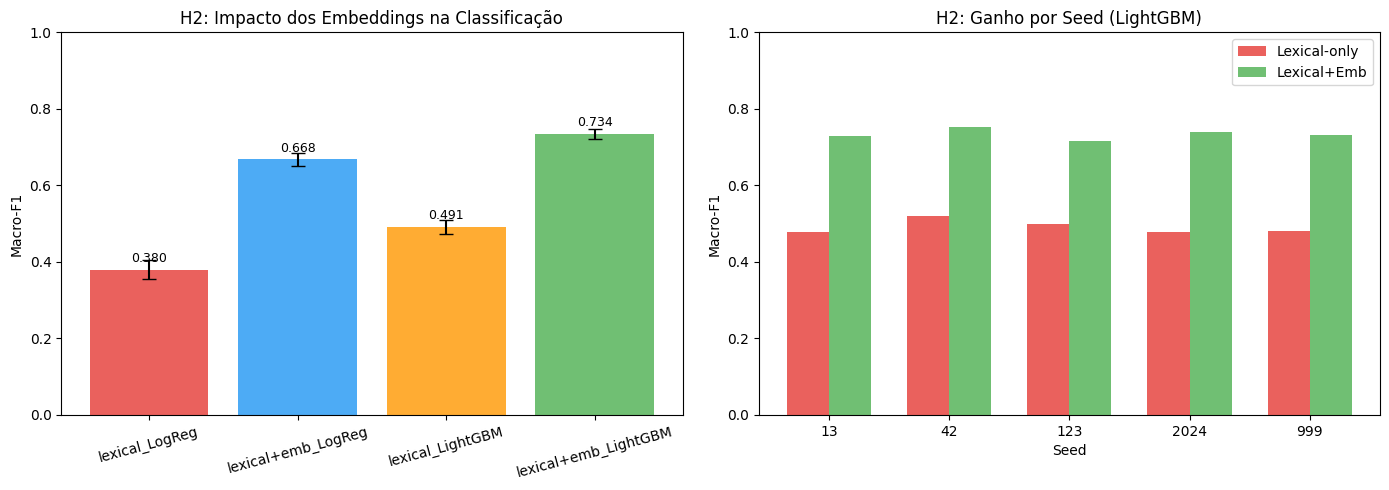

In [23]:
# === VISUALIZAÇÃO H2 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparação das 4 variantes
variants = list(df_h2.columns)
means = [df_h2[v].mean() for v in variants]
stds = [df_h2[v].std() for v in variants]
colors = ['#E53935', '#2196F3', '#FF9800', '#4CAF50']
bars = ax1.bar(variants, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax1.set_ylabel("Macro-F1")
ax1.set_title("H2: Impacto dos Embeddings na Classificação")
ax1.set_ylim(0, 1)
for bar, mean in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{mean:.3f}", ha='center', fontsize=9)
ax1.tick_params(axis='x', rotation=15)

# Gráfico 2: Ganho por seed (lexical vs lexical+emb, LightGBM)
seeds_labels = [str(s) for s in SEEDS]
lex_scores = [results_h2[s]["lexical_LightGBM"] for s in SEEDS]
full_scores = [results_h2[s]["lexical+emb_LightGBM"] for s in SEEDS]
x = np.arange(len(SEEDS))
w = 0.35
ax2.bar(x - w/2, lex_scores, w, label='Lexical-only', color='#E53935', alpha=0.8)
ax2.bar(x + w/2, full_scores, w, label='Lexical+Emb', color='#4CAF50', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(seeds_labels)
ax2.set_xlabel("Seed")
ax2.set_ylabel("Macro-F1")
ax2.set_title("H2: Ganho por Seed (LightGBM)")
ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6.3 H3: Regras Determinísticas + ML

> **Hipótese:** Regras determinísticas complementam a classificação por aprendizado de máquina.

**Três estratégias comparadas:**

> **Nota metodológica:** O baseline ML-only usa 395 features (sem nenhuma feature de regra). ML+Rules-feature adiciona 10 features binárias das regras (405 dims total), garantindo comparação isolada do impacto das regras.

| Estratégia | Descrição |
|:---|:---|
| ML-only | LightGBM sem regras (baseline) |
| ML+Rules-override | Regra dispara → sobrescreve predição do ML |
| ML+Rules-feature | Matches de regras como 10 features binárias adicionais |


In [24]:
# === EXPERIMENTO H3 ===

print("=" * 70)
print("HIPÓTESE H3: INTEGRAÇÃO DE REGRAS")
print("=" * 70)

# Baseline sem regras: remover features de regras (índices 11-12) de X_full
IDX_NO_RULES = list(range(11)) + list(range(13, X_full.shape[1]))
X_no_rules = X_full[:, IDX_NO_RULES]  # 395 features (sem rule_cancel, rule_complaint)

results_h3 = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Dados SEM regras (baseline limpo)
    X_train_nr = X_no_rules[train_mask]
    X_val_nr = X_no_rules[val_mask]
    X_test_nr = X_no_rules[test_mask]
    y_train = y_labels[train_mask]
    y_val = y_labels[val_mask]
    y_test = y_labels[test_mask]

    # 1. ML-only (sem NENHUMA feature de regra — 395 dims)
    if HAS_LIGHTGBM:
        clf = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        clf.fit(X_train_nr, y_train,
                eval_set=[(X_val_nr, y_val)],
                callbacks=[lgb.early_stopping(15, verbose=False)])
    else:
        clf = LogisticRegression(max_iter=2000, random_state=seed)
        clf.fit(X_train_nr, y_train)
    y_pred_ml = clf.predict(X_test_nr)
    f1_ml_only = f1_score(y_test, y_pred_ml, average='macro', zero_division=0)

    # 2. Rules-only
    test_windows_h3 = [all_windows[i] for i in range(len(all_windows)) if test_mask[i]]
    y_pred_rules = []
    for w in test_windows_h3:
        rule_res = evaluate_rules(w["window_text"])
        predicted = None
        for rule in RULES:
            if rule_res.get(rule["rule_id"], 0.0) > 0:
                predicted = rule["intent"]
                break
        y_pred_rules.append(predicted if predicted else "outros")
    f1_rules_only = f1_score(y_test, y_pred_rules, average='macro', zero_division=0)

    # 3. ML+Rules-override (modelo sem regras, override pela 1ª regra que dispara)
    # Ordem de prioridade: cancel > complaint > support > purchase > product > service > greeting > praise > contextual
    # Regras específicas (cancelamento, reclamação) têm prioridade sobre genéricas (saudação, elogio)
    y_pred_override = []
    for i, w in enumerate(test_windows_h3):
        rule_res = evaluate_rules(w["window_text"])
        rule_pred = None
        for rule in RULES:
            if rule_res.get(rule["rule_id"], 0.0) > 0:
                rule_pred = rule["intent"]
                break
        y_pred_override.append(rule_pred if rule_pred else y_pred_ml[i])
    f1_override = f1_score(y_test, y_pred_override, average='macro', zero_division=0)

    # 4. ML+Rules-feature (10 regras como features adicionais — 405 dims)
    train_windows_h3 = [all_windows[i] for i in range(len(all_windows)) if train_mask[i]]
    val_windows_h3 = [all_windows[i] for i in range(len(all_windows)) if val_mask[i]]

    rule_features_train = np.array([[evaluate_rules(w["window_text"]).get(r["rule_id"], 0.0) for r in RULES] for w in train_windows_h3])
    rule_features_val = np.array([[evaluate_rules(w["window_text"]).get(r["rule_id"], 0.0) for r in RULES] for w in val_windows_h3])
    rule_features_test = np.array([[evaluate_rules(w["window_text"]).get(r["rule_id"], 0.0) for r in RULES] for w in test_windows_h3])

    X_train_rf = np.hstack([X_train_nr, rule_features_train])
    X_val_rf = np.hstack([X_val_nr, rule_features_val])
    X_test_rf = np.hstack([X_test_nr, rule_features_test])

    if HAS_LIGHTGBM:
        clf_rf = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        clf_rf.fit(X_train_rf, y_train,
                   eval_set=[(X_val_rf, y_val)],
                   callbacks=[lgb.early_stopping(15, verbose=False)])
    else:
        clf_rf = LogisticRegression(max_iter=2000, random_state=seed)
        clf_rf.fit(X_train_rf, y_train)
    y_pred_rf = clf_rf.predict(X_test_rf)
    f1_rules_feature = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

    results_h3[seed] = {
        "ML-only": f1_ml_only,
        "Rules-only": f1_rules_only,
        "ML+Rules-override": f1_override,
        "ML+Rules-feature": f1_rules_feature,
    }
    print(f"  Seed {seed}: ML-only={f1_ml_only:.4f}, Rules={f1_rules_only:.4f}, "
          f"Override={f1_override:.4f}, Feature={f1_rules_feature:.4f}")

# Resultados
print("\n" + "=" * 70)
print("RESULTADOS H3: MACRO-F1 (média ± std sobre 5 seeds)")
print("=" * 70)
print("  Nota: ML-only usa 395 features (sem regras), ML+Rules-feature usa 405 features")
df_h3 = pd.DataFrame(results_h3).T
for col in df_h3.columns:
    mean = df_h3[col].mean()
    std = df_h3[col].std()
    print(f"  {col}: {mean:.4f} ± {std:.4f}")

HIPÓTESE H3: INTEGRAÇÃO DE REGRAS
  Seed 13: ML-only=0.7124, Rules=0.2760, Override=0.3548, Feature=0.7326
  Seed 42: ML-only=0.7275, Rules=0.3156, Override=0.3920, Feature=0.7431
  Seed 123: ML-only=0.7361, Rules=0.3023, Override=0.3825, Feature=0.7136
  Seed 2024: ML-only=0.7340, Rules=0.3096, Override=0.3862, Feature=0.7376
  Seed 999: ML-only=0.7199, Rules=0.2939, Override=0.3579, Feature=0.7253

RESULTADOS H3: MACRO-F1 (média ± std sobre 5 seeds)
  Nota: ML-only usa 395 features (sem regras), ML+Rules-feature usa 405 features
  ML-only: 0.7260 ± 0.0099
  Rules-only: 0.2995 ± 0.0154
  ML+Rules-override: 0.3747 ± 0.0171
  ML+Rules-feature: 0.7305 ± 0.0115


In [25]:
# === TESTE ESTATÍSTICO H3 ===

print("\n📊 Testes Estatísticos H3")
print("-" * 50)

# Comparar ML+Rules-feature vs ML-only
scores_ml_only = [results_h3[s]['ML-only'] for s in SEEDS]
scores_ml_rf = [results_h3[s]['ML+Rules-feature'] for s in SEEDS]
diff_h3 = np.array(scores_ml_rf) - np.array(scores_ml_only)
nonzero_h3 = diff_h3[diff_h3 != 0]

if len(nonzero_h3) >= 2:
    stat_h3, p_h3 = scipy_stats.wilcoxon(scores_ml_rf, scores_ml_only, alternative="greater")
    n_h3 = len(nonzero_h3)
    r_rb_h3 = 1 - (2 * stat_h3) / (n_h3 * (n_h3 + 1) / 2)
    print(f"  ML+Rules-feature vs ML-only:")
    print(f"  W={stat_h3:.1f}, p={p_h3:.6f}")
    print(f"  Significativo: {'SIM ✅' if p_h3 < 0.05 else 'NÃO ❌'}")
    print(f"  r_rb={r_rb_h3:.4f} ({'grande' if abs(r_rb_h3) > 0.5 else 'médio' if abs(r_rb_h3) > 0.3 else 'pequeno'})")
else:
    print("  ⚠️ Pares insuficientes para Wilcoxon (ML+Rules-feature vs ML-only)")

# Comparar ML+Rules-override vs ML-only
scores_ml_override = [results_h3[s]['ML+Rules-override'] for s in SEEDS]
diff_h3b = np.array(scores_ml_override) - np.array(scores_ml_only)
print(f"\n  ML+Rules-override vs ML-only:")
print(f"  Diferença média: {np.mean(diff_h3b):.4f}")
if np.mean(diff_h3b) < 0:
    print("  ⚠️ Override degrada performance — não aplicar Wilcoxon one-sided 'greater'")

# Bootstrap CI
print("\n📊 Bootstrap CI 95% — ML+Rules-feature vs ML-only")
rng_h3 = np.random.default_rng(42)
boot_h3 = []
for _ in range(10000):
    idx = rng_h3.integers(0, len(SEEDS), size=len(SEEDS))
    boot_h3.append(np.mean(np.array(scores_ml_rf)[idx] - np.array(scores_ml_only)[idx]))
print(f"  Diferença média: {np.mean(diff_h3):.4f}")
print(f"  IC 95%: [{np.percentile(boot_h3, 2.5):.4f}, {np.percentile(boot_h3, 97.5):.4f}]")

# F1 por classe (último seed como demonstração)
print("\n📊 F1 por Classe — ML+Rules-feature (seed=999, demonstrativo)")
print(classification_report(y_test, y_pred_rf, zero_division=0))



📊 Testes Estatísticos H3
--------------------------------------------------
  ML+Rules-feature vs ML-only:
  W=10.0, p=0.312500
  Significativo: NÃO ❌
  r_rb=-0.3333 (médio)

  ML+Rules-override vs ML-only:
  Diferença média: -0.3513
  ⚠️ Override degrada performance — não aplicar Wilcoxon one-sided 'greater'

📊 Bootstrap CI 95% — ML+Rules-feature vs ML-only
  Diferença média: 0.0045
  IC 95%: [-0.0096, 0.0154]

📊 F1 por Classe — ML+Rules-feature (seed=999, demonstrativo)
                 precision    recall  f1-score   support

   cancelamento       0.81      0.90      0.86       112
         compra       0.68      0.67      0.67       120
 duvida_produto       0.71      0.61      0.65       119
 duvida_servico       0.64      0.70      0.67       109
         elogio       0.92      0.82      0.87        96
     reclamacao       0.65      0.75      0.70       103
       saudacao       0.65      0.55      0.60       116
suporte_tecnico       0.76      0.83      0.79       116

       

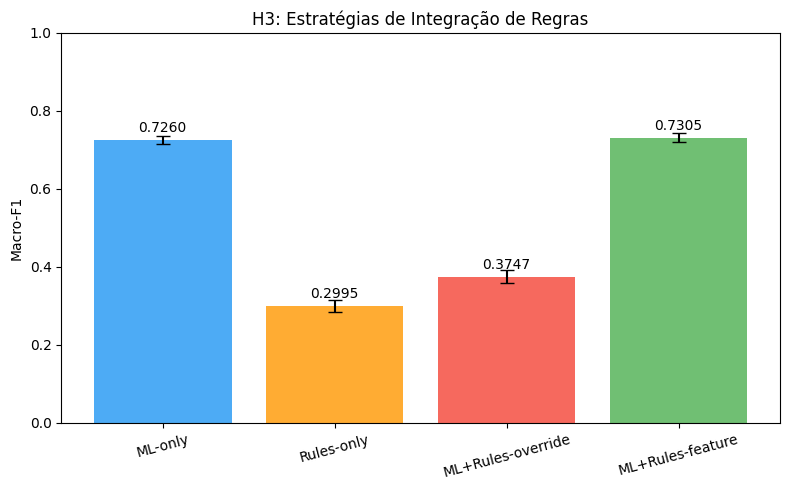

In [26]:
# === VISUALIZAÇÃO H3 ===

fig, ax = plt.subplots(figsize=(8, 5))
strategies = list(df_h3.columns)
means = [df_h3[s].mean() for s in strategies]
stds = [df_h3[s].std() for s in strategies]

colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
bars = ax.bar(strategies, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.set_ylabel("Macro-F1")
ax.set_title("H3: Estratégias de Integração de Regras")
ax.set_ylim(0, 1)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{mean:.4f}", ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 6.4 H4: Inferência Cascateada

> **Hipótese:** A combinação de dois classificadores em cascata (LogReg → LightGBM) melhora o Macro-F1 em relação ao classificador único, explorando a complementaridade entre modelos lineares e não-lineares.

**Estratégia:** O LogReg resolve casos "fáceis" com alta confiança. Casos ambíguos são encaminhados ao LightGBM, que tem maior capacidade discriminativa.

```
Entrada ──▶ [Stage 1: LogReg] ──▶ confiança ≥ threshold? ──SIM──▶ Predição Stage 1
                                           │
                                          NÃO
                                           │
                                    [Stage 2: LightGBM] ──▶ Predição Stage 2
```

**Métricas:**
- **Macro-F1** (primária) — a cascata melhora a qualidade preditiva?
- **Tempo de inferência** (secundária) — qual o custo adicional da cascata? O trade-off justifica a complexidade?

**Variantes:** 5 thresholds de confiança × 5 seeds.

In [27]:
# === EXPERIMENTO H4 ===

print("=" * 70)
print("HIPÓTESE H4: INFERÊNCIA CASCATEADA (F1 + TEMPO)")
print("=" * 70)

CASCADE_THRESHOLDS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
results_h4 = {s: {} for s in SEEDS}
timing_h4 = {s: {} for s in SEEDS}
cascade_stats = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids)))
    conv_intent_list = [intents_per_conv.get(c, 'outros') for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    X_train = X_full[train_mask]
    X_val = X_full[val_mask]
    y_train = y_labels[train_mask]
    y_val = y_labels[val_mask]
    X_test = X_full[test_mask]
    y_test = y_labels[test_mask]

    # Stage 1: LogReg
    stage1 = LogisticRegression(max_iter=2000, random_state=seed)
    stage1.fit(X_train, y_train)

    # Stage 2: LightGBM (otimizado)
    if HAS_LIGHTGBM:
        stage2 = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=300, random_state=seed, verbose=-1)
        stage2.fit(X_train, y_train,
                   eval_set=[(X_val, y_val)],
                   callbacks=[lgb.early_stopping(10, verbose=False)])
    else:
        stage2 = LogisticRegression(max_iter=2000, random_state=seed, C=10.0)
        stage2.fit(X_train, y_train)

    # === Baseline: LightGBM sozinho ===
    t0 = time.perf_counter()
    y_pred_uniform = stage2.predict(X_test)
    time_uniform = time.perf_counter() - t0
    f1_uniform = f1_score(y_test, y_pred_uniform, average='macro', zero_division=0)
    results_h4[seed]['LightGBM-only'] = f1_uniform
    timing_h4[seed]['LightGBM-only'] = time_uniform

    # === Baseline: LogReg sozinho ===
    t0 = time.perf_counter()
    y_pred_lr = stage1.predict(X_test)
    time_lr = time.perf_counter() - t0
    f1_lr = f1_score(y_test, y_pred_lr, average='macro', zero_division=0)
    results_h4[seed]['LogReg-only'] = f1_lr
    timing_h4[seed]['LogReg-only'] = time_lr

    # Stage 1 probabilidades
    stage1_proba = stage1.predict_proba(X_test)
    stage1_confidence = stage1_proba.max(axis=1)
    stage1_preds = stage1.classes_[stage1_proba.argmax(axis=1)]

    # Stage 2 probabilidades (para combinação)
    stage2_proba = stage2.predict_proba(X_test)
    stage2_preds = stage2.predict(X_test)

    # === Cascata: Stage 1 decide ou delega ao Stage 2 ===
    for threshold in CASCADE_THRESHOLDS:
        t0 = time.perf_counter()

        cascade_preds = []
        n_stage1_resolved = 0
        n_stage2_needed = 0

        for i in range(len(X_test)):
            if stage1_confidence[i] >= threshold:
                cascade_preds.append(stage1_preds[i])
                n_stage1_resolved += 1
            else:
                cascade_preds.append(stage2_preds[i])
                n_stage2_needed += 1

        time_cascade = time.perf_counter() - t0

        f1_cascade = f1_score(y_test, cascade_preds, average='macro', zero_division=0)
        stage1_pct = n_stage1_resolved / len(X_test) * 100

        key = f'cascade_t{threshold:.2f}'
        results_h4[seed][key] = f1_cascade
        timing_h4[seed][key] = time_cascade + time_lr  # Stage 1 + decisão
        cascade_stats[seed][key] = {
            'stage1_resolved': n_stage1_resolved,
            'stage2_needed': n_stage2_needed,
            'stage1_pct': stage1_pct,
        }

    # === Ensemble: média das probabilidades dos dois modelos ===
    t0 = time.perf_counter()
    ensemble_proba = 0.5 * stage1_proba + 0.5 * stage2_proba
    ensemble_preds = stage1.classes_[ensemble_proba.argmax(axis=1)]
    time_ensemble = time.perf_counter() - t0 + time_lr + time_uniform
    f1_ensemble = f1_score(y_test, ensemble_preds, average='macro', zero_division=0)
    results_h4[seed]['Ensemble-avg'] = f1_ensemble
    timing_h4[seed]['Ensemble-avg'] = time_ensemble

    # === Ensemble ponderado: peso maior para LightGBM ===
    t0 = time.perf_counter()
    ensemble_w_proba = 0.3 * stage1_proba + 0.7 * stage2_proba
    ensemble_w_preds = stage1.classes_[ensemble_w_proba.argmax(axis=1)]
    time_ensemble_w = time.perf_counter() - t0 + time_lr + time_uniform
    f1_ensemble_w = f1_score(y_test, ensemble_w_preds, average='macro', zero_division=0)
    results_h4[seed]['Ensemble-0.3/0.7'] = f1_ensemble_w
    timing_h4[seed]['Ensemble-0.3/0.7'] = time_ensemble_w

    print(f"  Seed {seed}: LGB={f1_uniform:.4f}, LR={f1_lr:.4f}, "
          f"Cascade-0.70={results_h4[seed].get('cascade_t0.70',0):.4f}, "
          f"Ensemble={f1_ensemble:.4f}, Ens-0.3/0.7={f1_ensemble_w:.4f}")

# === Resultados ===
print("\n" + "=" * 70)
print("RESULTADOS H4: MACRO-F1 (média ± std sobre 5 seeds)")
print("=" * 70)

df_h4 = pd.DataFrame(results_h4).T
df_timing = pd.DataFrame(timing_h4).T

# Ordenar por F1 médio
col_order = df_h4.mean().sort_values(ascending=False).index
for col in col_order:
    mean_f1 = df_h4[col].mean()
    std_f1 = df_h4[col].std()
    mean_time = df_timing[col].mean() * 1000
    delta_f1 = mean_f1 - df_h4['LightGBM-only'].mean()
    marker = " ← baseline" if col == 'LightGBM-only' else ""
    print(f"  {col:20s}: F1={mean_f1:.4f} ± {std_f1:.4f}  Δ={delta_f1:+.4f}  tempo={mean_time:.1f}ms{marker}")

# Teste estatístico: melhor método vs LightGBM-only
print("\n📊 Teste Estatístico H4 — Wilcoxon Signed-Rank")
print("-" * 50)

best_col = df_h4.mean().idxmax()
if best_col != 'LightGBM-only':
    scores_best = [results_h4[s][best_col] for s in SEEDS]
    scores_base = [results_h4[s]['LightGBM-only'] for s in SEEDS]
    diff_h4 = np.array(scores_best) - np.array(scores_base)
    nonzero = diff_h4[diff_h4 != 0]

    print(f"  Comparação: {best_col} vs LightGBM-only")
    print(f"  Diferença média F1: {np.mean(diff_h4):+.4f}")

    if len(nonzero) >= 2:
        stat_h4, p_h4 = scipy_stats.wilcoxon(scores_best, scores_base, alternative="greater")
        n_h4 = len(nonzero)
        r_rb_h4 = 1 - (2 * stat_h4) / (n_h4 * (n_h4 + 1) / 2)
        print(f"  W={stat_h4:.1f}, p={p_h4:.6f}")
        print(f"  Significativo: {'SIM ✅' if p_h4 < 0.05 else 'NÃO ❌'}")
        print(f"  r_rb={r_rb_h4:.4f}")

    # Bootstrap CI
    rng_h4 = np.random.default_rng(42)
    boot_h4 = []
    for _ in range(10000):
        idx = rng_h4.integers(0, len(SEEDS), size=len(SEEDS))
        boot_h4.append(np.mean(np.array(scores_best)[idx] - np.array(scores_base)[idx]))
    print(f"  Bootstrap CI 95%: [{np.percentile(boot_h4, 2.5):.4f}, {np.percentile(boot_h4, 97.5):.4f}]")
else:
    print(f"  LightGBM-only é o melhor método — cascata não melhora F1")

# Custo adicional
print(f"\n📊 Análise de Custo (tempo)")
time_base = df_timing['LightGBM-only'].mean() * 1000
for col in col_order:
    if col == 'LightGBM-only':
        continue
    t = df_timing[col].mean() * 1000
    overhead = (t / time_base - 1) * 100 if time_base > 0 else 0
    f1_gain = (df_h4[col].mean() - df_h4['LightGBM-only'].mean())
    print(f"  {col:20s}: {t:.1f}ms ({overhead:+.0f}% vs baseline), ΔF1={f1_gain:+.4f}")

# Cascata stats
print(f"\n📊 Proporção resolvida pelo Stage 1 (LogReg):")
for t in CASCADE_THRESHOLDS:
    key = f'cascade_t{t:.2f}'
    pcts = [cascade_stats[s][key]['stage1_pct'] for s in SEEDS]
    print(f"  threshold={t:.2f}: {np.mean(pcts):.1f}% resolvido pelo Stage 1 "
          f"({100-np.mean(pcts):.1f}% vai ao Stage 2)")

HIPÓTESE H4: INFERÊNCIA CASCATEADA (F1 + TEMPO)
  Seed 13: LGB=0.7285, LR=0.6496, Cascade-0.70=0.7228, Ensemble=0.7155, Ens-0.3/0.7=0.7185
  Seed 42: LGB=0.7539, LR=0.6724, Cascade-0.70=0.7502, Ensemble=0.7349, Ens-0.3/0.7=0.7466
  Seed 123: LGB=0.7166, LR=0.6783, Cascade-0.70=0.7101, Ensemble=0.7222, Ens-0.3/0.7=0.7282
  Seed 2024: LGB=0.7395, LR=0.6888, Cascade-0.70=0.7393, Ensemble=0.7331, Ens-0.3/0.7=0.7405
  Seed 999: LGB=0.7321, LR=0.6494, Cascade-0.70=0.7286, Ensemble=0.7186, Ens-0.3/0.7=0.7288

RESULTADOS H4: MACRO-F1 (média ± std sobre 5 seeds)
  LightGBM-only       : F1=0.7341 ± 0.0138  Δ=+0.0000  tempo=8.4ms ← baseline
  cascade_t0.95       : F1=0.7339 ± 0.0142  Δ=-0.0002  tempo=3.4ms
  cascade_t0.90       : F1=0.7331 ± 0.0137  Δ=-0.0011  tempo=3.3ms
  Ensemble-0.3/0.7    : F1=0.7325 ± 0.0111  Δ=-0.0016  tempo=10.8ms
  cascade_t0.80       : F1=0.7321 ± 0.0147  Δ=-0.0020  tempo=3.3ms
  cascade_t0.70       : F1=0.7302 ± 0.0154  Δ=-0.0039  tempo=3.4ms
  Ensemble-avg        : F1

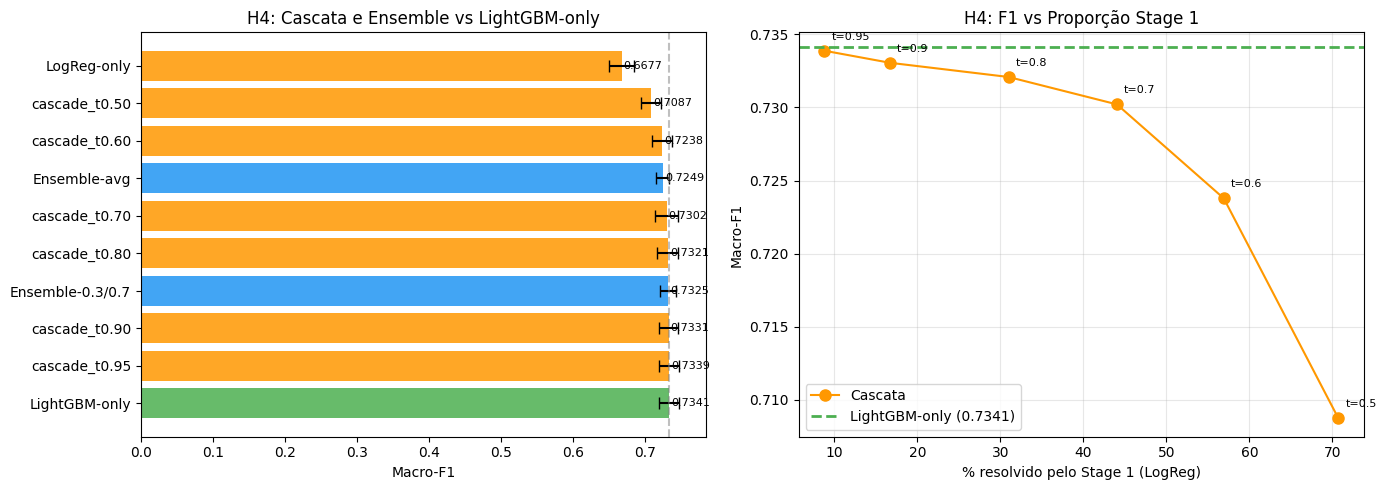


📊 Resumo H4: F1 × Tempo × Proporção Stage 1
---------------------------------------------------------------------------
                Método    Macro-F1       ΔF1     Tempo   Stage1%
---------------------------------------------------------------------------
         LightGBM-only      0.7341   +0.0000      8.4ms        0% ←
         cascade_t0.95      0.7339   -0.0002      3.4ms        9%
         cascade_t0.90      0.7331   -0.0011      3.3ms       17%
      Ensemble-0.3/0.7      0.7325   -0.0016     10.8ms         —
         cascade_t0.80      0.7321   -0.0020      3.3ms       31%
         cascade_t0.70      0.7302   -0.0039      3.4ms       44%
          Ensemble-avg      0.7249   -0.0092     10.8ms         —
         cascade_t0.60      0.7238   -0.0103      3.4ms       57%
         cascade_t0.50      0.7087   -0.0254      3.5ms       71%
           LogReg-only      0.6677   -0.0664      2.3ms      100%


In [28]:
# === VISUALIZAÇÃO H4 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: F1 por método (barras)
methods = list(df_h4.mean().sort_values(ascending=False).index)
means = [df_h4[m].mean() for m in methods]
stds = [df_h4[m].std() for m in methods]
colors = ['#4CAF50' if m == 'LightGBM-only' else '#2196F3' if 'Ensemble' in m else '#FF9800' for m in methods]

bars = ax1.barh(methods, means, xerr=stds, capsize=4, color=colors, alpha=0.85)
ax1.axvline(x=df_h4['LightGBM-only'].mean(), color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel("Macro-F1")
ax1.set_title("H4: Cascata e Ensemble vs LightGBM-only")
for bar, mean in zip(bars, means):
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f"{mean:.4f}", va='center', fontsize=8)

# Gráfico 2: F1 vs % resolvido pelo Stage 1
cascade_cols = [c for c in df_h4.columns if 'cascade' in c]
f1_vals = [df_h4[c].mean() for c in cascade_cols]
stage1_pcts = []
for c in cascade_cols:
    pcts = [cascade_stats[s][c]['stage1_pct'] for s in SEEDS]
    stage1_pcts.append(np.mean(pcts))

ax2.plot(stage1_pcts, f1_vals, 'o-', color='#FF9800', markersize=8, label='Cascata')
ax2.axhline(df_h4['LightGBM-only'].mean(), color='#4CAF50', linestyle='--',
            linewidth=2, label=f'LightGBM-only ({df_h4["LightGBM-only"].mean():.4f})')
for pct, f1, t in zip(stage1_pcts, f1_vals, CASCADE_THRESHOLDS):
    ax2.annotate(f't={t}', (pct, f1), textcoords="offset points",
                 xytext=(5, 8), fontsize=8)
ax2.set_xlabel("% resolvido pelo Stage 1 (LogReg)")
ax2.set_ylabel("Macro-F1")
ax2.set_title("H4: F1 vs Proporção Stage 1")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tabela resumo
print("\n📊 Resumo H4: F1 × Tempo × Proporção Stage 1")
print("-" * 75)
print(f"  {'Método':>20s}  {'Macro-F1':>10s}  {'ΔF1':>8s}  {'Tempo':>8s}  {'Stage1%':>8s}")
print("-" * 75)
f1_base = df_h4['LightGBM-only'].mean()
for col in df_h4.mean().sort_values(ascending=False).index:
    f1 = df_h4[col].mean()
    delta = f1 - f1_base
    t = df_timing[col].mean() * 1000
    if 'cascade' in col:
        pcts = [cascade_stats[s][col]['stage1_pct'] for s in SEEDS]
        s1 = f"{np.mean(pcts):.0f}%"
    elif col == 'LogReg-only':
        s1 = "100%"
    elif col == 'LightGBM-only':
        s1 = "0%"
    else:
        s1 = "—"
    marker = " ←" if col == 'LightGBM-only' else ""
    print(f"  {col:>20s}  {f1:>10.4f}  {delta:>+8.4f}  {t:>7.1f}ms  {s1:>8s}{marker}")

## 6.5 Estudo de Ablação

Quantificamos a contribuição marginal de cada família de features removendo-as uma a uma do modelo completo (397 dims). Isso identifica quais componentes são essenciais e quais são redundantes.

| Configuração | Features | O que mede |
|:---|:---:|:---|
| Full (397) | todas | Modelo completo (baseline) |
| −Embeddings (13) | lex + struct + rules | Contribuição dos embeddings |
| −Lexicais (390) | struct + rules + emb | Contribuição das features lexicais |
| −Regras (395) | lex + struct + emb | Contribuição das regras |
| −Estruturais (393) | lex + rules + emb | Contribuição das features estruturais |
| Embedding-only (384) | emb | Embeddings sozinhos |
| Lex+Struct (11) | lex + struct (sem regras) | Features manuais sozinhas |

In [29]:
# === ABLAÇÃO ===

print("=" * 70)
print("ESTUDO DE ABLAÇÃO")
print("=" * 70)

# Índices de features
IDX_LEXICAL = list(range(7))          # 0-6
IDX_STRUCTURAL = list(range(7, 11))   # 7-10
IDX_RULES = list(range(11, 13))       # 11-12
IDX_EMBEDDING = list(range(13, 397))  # 13-396

ablation_configs = {
    "Full (397)": list(range(397)),
    "-Embeddings (13)": IDX_LEXICAL + IDX_STRUCTURAL + IDX_RULES,
    "-Lexicais (390)": IDX_STRUCTURAL + IDX_RULES + IDX_EMBEDDING,
    "-Regras (395)": IDX_LEXICAL + IDX_STRUCTURAL + IDX_EMBEDDING,
    "-Estruturais (393)": IDX_LEXICAL + IDX_RULES + IDX_EMBEDDING,
    "Embedding-only (384)": IDX_EMBEDDING,
    "Lex+Struct (11)": IDX_LEXICAL + IDX_STRUCTURAL,
}

results_ablation = {}

for config_name, feature_indices in ablation_configs.items():
    f1_scores_per_seed = []

    for seed in SEEDS:
        conv_list = np.array(list(set(conv_ids)))
        conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
        train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
        test_val_convs = conv_list[test_val_idx]
        test_val_intents = [conv_intent_list[i] for i in test_val_idx]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
        val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

        train_convs = set(conv_list[train_idx])
        val_convs = set(test_val_convs[val_idx])
        test_convs_set = set(test_val_convs[test_idx])

        train_mask = np.array([c in train_convs for c in conv_ids])
        val_mask = np.array([c in val_convs for c in conv_ids])
        test_mask = np.array([c in test_convs_set for c in conv_ids])

        X_train_ab = X_full[train_mask][:, feature_indices]
        X_val_ab = X_full[val_mask][:, feature_indices]
        y_train_ab = y_labels[train_mask]
        y_val_ab = y_labels[val_mask]
        X_test_ab = X_full[test_mask][:, feature_indices]
        y_test_ab = y_labels[test_mask]

        if HAS_LIGHTGBM:
            clf = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
            clf.fit(X_train_ab, y_train_ab,
                    eval_set=[(X_val_ab, y_val_ab)],
                    callbacks=[lgb.early_stopping(15, verbose=False)])
        else:
            clf = LogisticRegression(max_iter=2000, random_state=seed)
            clf.fit(X_train_ab, y_train_ab)
        y_pred = clf.predict(X_test_ab)
        f1 = f1_score(y_test_ab, y_pred, average='macro', zero_division=0)
        f1_scores_per_seed.append(f1)

    results_ablation[config_name] = {
        "mean_f1": np.mean(f1_scores_per_seed),
        "std_f1": np.std(f1_scores_per_seed),
        "n_features": len(feature_indices),
    }
    print(f"  {config_name}: F1={np.mean(f1_scores_per_seed):.4f} ± {np.std(f1_scores_per_seed):.4f}")

# Tabela
print("\n" + "=" * 70)
df_ablation = pd.DataFrame(results_ablation).T
print(df_ablation.to_string())

ESTUDO DE ABLAÇÃO
  Full (397): F1=0.7343 ± 0.0123
  -Embeddings (13): F1=0.4909 ± 0.0167
  -Lexicais (390): F1=0.7033 ± 0.0150
  -Regras (395): F1=0.7260 ± 0.0088
  -Estruturais (393): F1=0.7343 ± 0.0123
  Embedding-only (384): F1=0.7029 ± 0.0108
  Lex+Struct (11): F1=0.4297 ± 0.0077

                       mean_f1    std_f1  n_features
Full (397)            0.734264  0.012330       397.0
-Embeddings (13)      0.490875  0.016710        13.0
-Lexicais (390)       0.703314  0.014961       390.0
-Regras (395)         0.725987  0.008815       395.0
-Estruturais (393)    0.734264  0.012330       393.0
Embedding-only (384)  0.702949  0.010770       384.0
Lex+Struct (11)       0.429665  0.007658        11.0


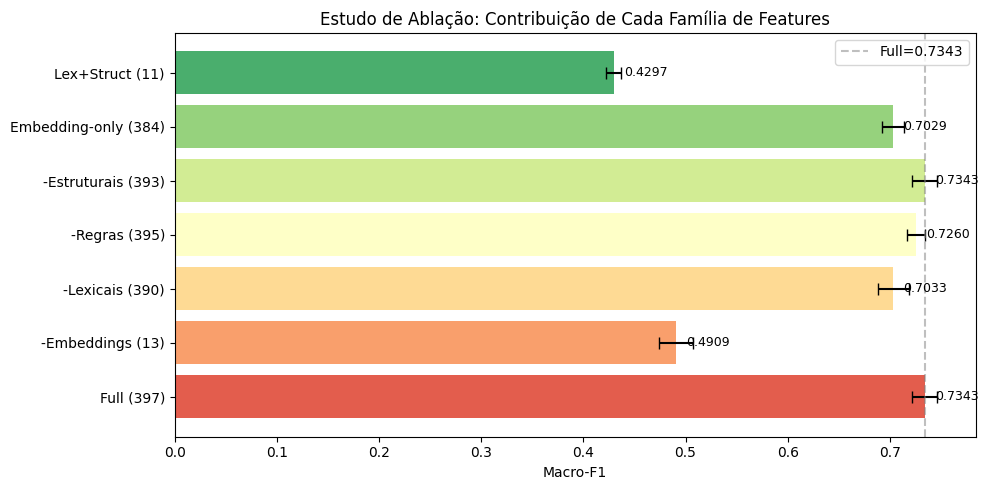

In [30]:
# === VISUALIZAÇÃO ABLAÇÃO ===

fig, ax = plt.subplots(figsize=(10, 5))
configs = list(results_ablation.keys())
means = [results_ablation[c]["mean_f1"] for c in configs]
stds = [results_ablation[c]["std_f1"] for c in configs]

colors = sns.color_palette("RdYlGn", len(configs))
bars = ax.barh(configs, means, xerr=stds, capsize=4, color=colors, alpha=0.85)
ax.set_xlabel("Macro-F1")
ax.set_title("Estudo de Ablação: Contribuição de Cada Família de Features")
ax.axvline(x=means[0], color='gray', linestyle='--', alpha=0.5, label=f'Full={means[0]:.4f}')
ax.legend()
for bar, mean in zip(bars, means):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{mean:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 6.6 Agregação Janela → Conversa

Agrega predições no nível da janela para o nível da conversa usando **média das probabilidades** (conforme descrito no pipeline, Stage 2 §6).

Isso permite avaliar a performance do classificador na granularidade que importa ao usuário final: a conversa inteira, não janelas individuais.

| Nível | Unidade | Método |
|:---|:---|:---|
| Janela | Segmento de 5 turnos | Predição direta do LightGBM |
| Conversa | Interação completa | Média das probabilidades das janelas → argmax |

In [31]:
# === AGREGAÇÃO JANELA → CONVERSA ===
# Método: média das probabilidades preditas por janela, decisão por argmax.

print("=" * 70)
print("AGREGAÇÃO JANELA → CONVERSA (média de probabilidades)")
print("=" * 70)

agg_results = {}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Treinar modelo completo (397 features)
    if HAS_LIGHTGBM:
        clf_agg = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        clf_agg.fit(X_full[train_mask], y_labels[train_mask],
                    eval_set=[(X_full[val_mask], y_labels[val_mask])],
                    callbacks=[lgb.early_stopping(15, verbose=False)])
    else:
        clf_agg = LogisticRegression(max_iter=2000, random_state=seed)
        clf_agg.fit(X_full[train_mask], y_labels[train_mask])

    # Predições no nível da janela
    proba_windows = clf_agg.predict_proba(X_full[test_mask])
    pred_windows = clf_agg.predict(X_full[test_mask])
    classes = clf_agg.classes_

    # F1 no nível da janela
    f1_window = f1_score(y_labels[test_mask], pred_windows, average='macro', zero_division=0)

    # Agregar por conversa: média das probabilidades
    test_conv_ids = conv_ids[test_mask]
    conv_proba = {}
    conv_true = {}

    for i, cid in enumerate(test_conv_ids):
        if cid not in conv_proba:
            conv_proba[cid] = []
            conv_true[cid] = y_labels[test_mask][i]
        conv_proba[cid].append(proba_windows[i])

    y_conv_true = []
    y_conv_pred = []
    for cid in conv_proba:
        mean_p = np.mean(conv_proba[cid], axis=0)
        y_conv_pred.append(classes[np.argmax(mean_p)])
        y_conv_true.append(conv_true[cid])

    f1_conv = f1_score(y_conv_true, y_conv_pred, average='macro', zero_division=0)

    agg_results[seed] = {
        "f1_window": f1_window,
        "f1_conversation": f1_conv,
        "n_windows": int(test_mask.sum()),
        "n_conversations": len(conv_proba),
    }
    print(f"  Seed {seed}: F1_janela={f1_window:.4f}, F1_conversa={f1_conv:.4f} "
          f"({len(conv_proba)} conversas, {int(test_mask.sum())} janelas)")

# Resumo
print("\n" + "=" * 70)
f1w_mean = np.mean([r["f1_window"] for r in agg_results.values()])
f1c_mean = np.mean([r["f1_conversation"] for r in agg_results.values()])
f1w_std = np.std([r["f1_window"] for r in agg_results.values()])
f1c_std = np.std([r["f1_conversation"] for r in agg_results.values()])
delta = f1c_mean - f1w_mean

print(f"  Macro-F1 (janela):    {f1w_mean:.4f} ± {f1w_std:.4f}")
print(f"  Macro-F1 (conversa):  {f1c_mean:.4f} ± {f1c_std:.4f}")
print(f"  Δ F1 (conversa - janela): {delta:+.4f}")

if delta > 0:
    print(f"\n  ✅ Agregação por média de probabilidades melhora a predição no nível da conversa")
else:
    print(f"\n  ⚠️ Agregação não melhorou — possível efeito de janelas ruidosas")

# F1 por classe (último seed)
print(f"\n📊 F1 por Classe — nível conversa (seed={SEEDS[-1]})")
print(classification_report(y_conv_true, y_conv_pred, zero_division=0))

AGREGAÇÃO JANELA → CONVERSA (média de probabilidades)
  Seed 13: F1_janela=0.7285, F1_conversa=0.7470 (318 conversas, 888 janelas)
  Seed 42: F1_janela=0.7539, F1_conversa=0.7985 (318 conversas, 895 janelas)
  Seed 123: F1_janela=0.7166, F1_conversa=0.7764 (318 conversas, 893 janelas)
  Seed 2024: F1_janela=0.7395, F1_conversa=0.7621 (318 conversas, 882 janelas)
  Seed 999: F1_janela=0.7328, F1_conversa=0.7700 (318 conversas, 891 janelas)

  Macro-F1 (janela):    0.7343 ± 0.0123
  Macro-F1 (conversa):  0.7708 ± 0.0170
  Δ F1 (conversa - janela): +0.0365

  ✅ Agregação por média de probabilidades melhora a predição no nível da conversa

📊 F1 por Classe — nível conversa (seed=999)
                 precision    recall  f1-score   support

   cancelamento       0.83      0.97      0.90        40
         compra       0.72      0.70      0.71        40
 duvida_produto       0.79      0.68      0.73        40
 duvida_servico       0.74      0.79      0.77        39
         elogio       0.92

## 6.7 Análise Complementar

### Avaliação em dados originais vs sintéticos
O corpus contém 676 conversas originais e 1.444 sintéticas. Reportar F1 separadamente demonstra que o modelo generaliza para dados reais, não apenas para padrões aprendidos das sintéticas.

### Matriz de confusão
Visualiza quais classes o modelo confunde com mais frequência.

### Importância de features
Identifica quais das 397 features o LightGBM considera mais relevantes para a classificação.

In [32]:
# === F1 EM DADOS ORIGINAIS vs SINTÉTICOS ===

print("=" * 70)
print("AVALIAÇÃO: DADOS ORIGINAIS vs SINTÉTICOS")
print("=" * 70)

# Mapear conv_id → _synthetic
conv_is_synthetic = {}
for _, row in df_original.iterrows():
    conv_is_synthetic[row['conv_id']] = bool(row.get('_synthetic', False))

results_split = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Treinar modelo
    if HAS_LIGHTGBM:
        clf_eval = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=300, random_state=seed, verbose=-1)
        clf_eval.fit(X_full[train_mask], y_labels[train_mask],
                     eval_set=[(X_full[val_mask], y_labels[val_mask])],
                     callbacks=[lgb.early_stopping(10, verbose=False)])
    else:
        clf_eval = LogisticRegression(max_iter=2000, random_state=seed)
        clf_eval.fit(X_full[train_mask], y_labels[train_mask])

    y_pred_all = clf_eval.predict(X_full[test_mask])
    test_conv_ids_arr = conv_ids[test_mask]
    y_test_arr = y_labels[test_mask]

    # F1 total
    f1_all = f1_score(y_test_arr, y_pred_all, average='macro', zero_division=0)

    # Separar janelas por origem
    orig_mask_test = np.array([not conv_is_synthetic.get(c, False) for c in test_conv_ids_arr])
    syn_mask_test = ~orig_mask_test

    f1_orig = f1_score(y_test_arr[orig_mask_test], y_pred_all[orig_mask_test],
                       average='macro', zero_division=0) if orig_mask_test.sum() > 0 else 0
    f1_syn = f1_score(y_test_arr[syn_mask_test], y_pred_all[syn_mask_test],
                      average='macro', zero_division=0) if syn_mask_test.sum() > 0 else 0

    results_split[seed] = {
        'all': f1_all,
        'original': f1_orig,
        'synthetic': f1_syn,
        'n_orig': int(orig_mask_test.sum()),
        'n_syn': int(syn_mask_test.sum()),
    }

# Resultados
print(f"\n📊 Macro-F1 por origem (média ± std sobre 5 seeds):")
for key, label in [('all', 'Todos'), ('original', 'Originais'), ('synthetic', 'Sintéticas')]:
    scores = [results_split[s][key] for s in SEEDS]
    n_samples = [results_split[s].get(f'n_{key[:4]}', results_split[s].get(f'n_{key[:3]}', '?')) for s in SEEDS]
    print(f"   {label:12s}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Detalhe por seed
print(f"\n📊 Detalhe por seed:")
print(f"   {'Seed':>6s}  {'Todos':>8s}  {'Originais':>10s}  {'Sintéticas':>11s}  {'N_orig':>7s}  {'N_syn':>6s}")
for seed in SEEDS:
    r = results_split[seed]
    print(f"   {seed:>6d}  {r['all']:>8.4f}  {r['original']:>10.4f}  {r['synthetic']:>11.4f}  {r['n_orig']:>7d}  {r['n_syn']:>6d}")

delta = np.mean([results_split[s]['original'] for s in SEEDS]) - np.mean([results_split[s]['synthetic'] for s in SEEDS])
print(f"\n   Δ (originais - sintéticas): {delta:+.4f}")
if abs(delta) < 0.05:
    print("   ✅ Performance similar — modelo generaliza bem para ambos")
elif delta > 0:
    print("   ⚠️ Modelo performa melhor em originais — sintéticas podem ter padrões diferentes")
else:
    print("   ⚠️ Modelo performa melhor em sintéticas — possível viés nos dados gerados")

AVALIAÇÃO: DADOS ORIGINAIS vs SINTÉTICOS

📊 Macro-F1 por origem (média ± std sobre 5 seeds):
   Todos       : 0.7341 ± 0.0123
   Originais   : 0.6082 ± 0.0169
   Sintéticas  : 0.7861 ± 0.0276

📊 Detalhe por seed:
     Seed     Todos   Originais   Sintéticas   N_orig   N_syn
       13    0.7285      0.6304       0.7812      341     547
       42    0.7539      0.6149       0.8045      262     633
      123    0.7166      0.6182       0.7353      276     617
     2024    0.7395      0.5929       0.7960      244     638
      999    0.7321      0.5847       0.8137      307     584

   Δ (originais - sintéticas): -0.1779
   ⚠️ Modelo performa melhor em sintéticas — possível viés nos dados gerados


📊 Matriz de Confusão (seed=999, nível janela)


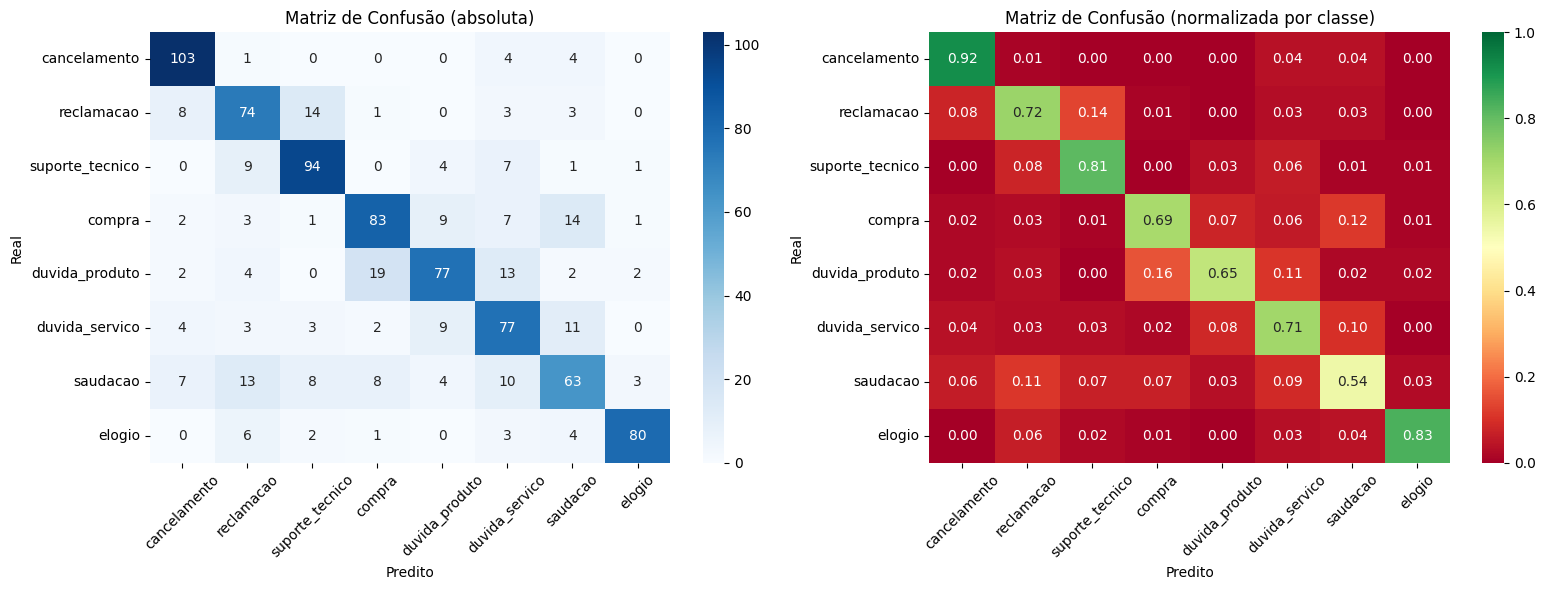


📊 Maiores confusões (fora da diagonal):
   duvida_produto       → compra              :  19 (16%)
   reclamacao           → suporte_tecnico     :  14 (14%)
   compra               → saudacao            :  14 (12%)
   duvida_produto       → duvida_servico      :  13 (11%)
   saudacao             → reclamacao          :  13 (11%)
   duvida_servico       → saudacao            :  11 (10%)
   saudacao             → duvida_servico      :  10 (9%)
   suporte_tecnico      → reclamacao          :   9 (8%)
   compra               → duvida_produto      :   9 (8%)
   duvida_servico       → duvida_produto      :   9 (8%)


In [33]:
# === MATRIZ DE CONFUSÃO ===

print("📊 Matriz de Confusão (seed=999, nível janela)")

# Usar o último modelo treinado (seed=999)
seed = SEEDS[-1]
conv_list = np.array(list(set(conv_ids)))
conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
test_val_convs = conv_list[test_val_idx]
test_val_intents = [conv_intent_list[i] for i in test_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
train_convs = set(conv_list[train_idx])
val_convs = set(test_val_convs[val_idx])
test_convs_set = set(test_val_convs[test_idx])
train_mask = np.array([c in train_convs for c in conv_ids])
val_mask = np.array([c in val_convs for c in conv_ids])
test_mask = np.array([c in test_convs_set for c in conv_ids])

if HAS_LIGHTGBM:
    clf_cm = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=300, random_state=seed, verbose=-1)
    clf_cm.fit(X_full[train_mask], y_labels[train_mask],
               eval_set=[(X_full[val_mask], y_labels[val_mask])],
               callbacks=[lgb.early_stopping(10, verbose=False)])
else:
    clf_cm = LogisticRegression(max_iter=2000, random_state=seed)
    clf_cm.fit(X_full[train_mask], y_labels[train_mask])

y_pred_cm = clf_cm.predict(X_full[test_mask])
y_test_cm = y_labels[test_mask]

# Confusion matrix
cm = confusion_matrix(y_test_cm, y_pred_cm, labels=INTENT_TAXONOMY)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=INTENT_TAXONOMY,
            yticklabels=INTENT_TAXONOMY, ax=ax1)
ax1.set_xlabel('Predito')
ax1.set_ylabel('Real')
ax1.set_title('Matriz de Confusão (absoluta)')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# Normalizada
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', xticklabels=INTENT_TAXONOMY,
            yticklabels=INTENT_TAXONOMY, ax=ax2, vmin=0, vmax=1)
ax2.set_xlabel('Predito')
ax2.set_ylabel('Real')
ax2.set_title('Matriz de Confusão (normalizada por classe)')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Identificar maiores confusões
print("\n📊 Maiores confusões (fora da diagonal):")
confusions = []
for i, true_cls in enumerate(INTENT_TAXONOMY):
    for j, pred_cls in enumerate(INTENT_TAXONOMY):
        if i != j and cm[i, j] > 0:
            confusions.append((true_cls, pred_cls, cm[i, j], cm_normalized[i, j]))
confusions.sort(key=lambda x: -x[2])
for true_cls, pred_cls, count, pct in confusions[:10]:
    print(f"   {true_cls:20s} → {pred_cls:20s}: {count:3d} ({pct:.0%})")

📊 Top 30 Features (LightGBM — importância por ganho)


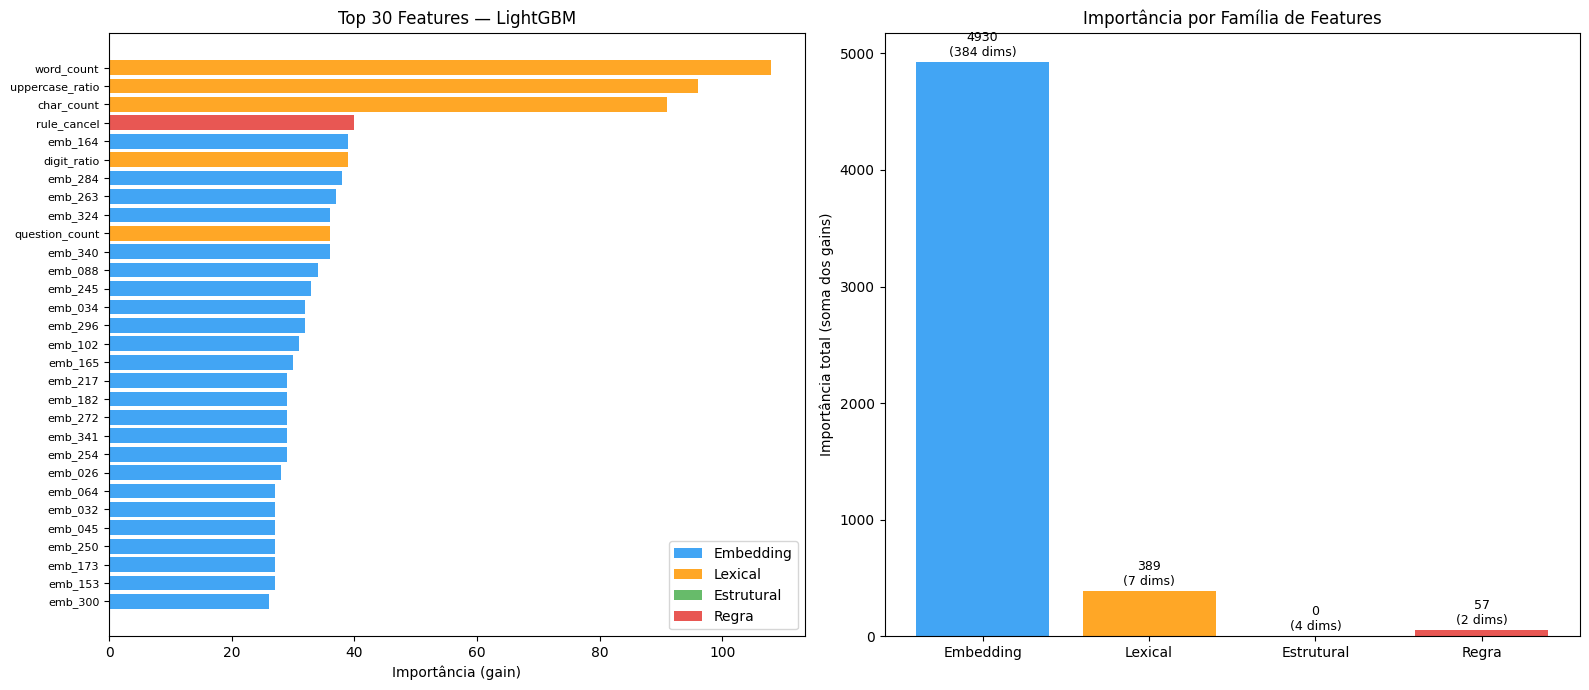


📊 Contribuição por família:
   Embedding   :     4930 ( 91.7%) — 384 features
   Lexical     :      389 (  7.2%) — 7 features
   Estrutural  :        0 (  0.0%) — 4 features
   Regra       :       57 (  1.1%) — 2 features


In [34]:
# === IMPORTÂNCIA DE FEATURES ===

if HAS_LIGHTGBM:
    print("📊 Top 30 Features (LightGBM — importância por ganho)")

    # Usar o último modelo treinado
    importances = clf_cm.feature_importances_

    # Nomes das features
    feature_names = (
        ['char_count', 'word_count', 'avg_word_length', 'question_count',
         'exclamation_count', 'uppercase_ratio', 'digit_ratio',  # 7 lexicais
         'is_customer', 'is_agent', 'turn_count', 'speaker_count',  # 4 estruturais
         'rule_cancel', 'rule_complaint']  # 2 regras
        + [f'emb_{i:03d}' for i in range(EMBEDDING_DIM)]  # 384 embeddings
    )

    # Ordenar por importância
    sorted_idx = np.argsort(importances)[::-1]

    # Categorizar
    def categorize_feature(name):
        if name.startswith('emb_'):
            return 'Embedding'
        elif name.startswith('rule_'):
            return 'Regra'
        elif name in ['is_customer', 'is_agent', 'turn_count', 'speaker_count']:
            return 'Estrutural'
        else:
            return 'Lexical'

    # Top 30
    top_n = 30
    top_names = [feature_names[i] for i in sorted_idx[:top_n]]
    top_values = importances[sorted_idx[:top_n]]
    top_cats = [categorize_feature(n) for n in top_names]

    cat_colors = {'Embedding': '#2196F3', 'Lexical': '#FF9800',
                  'Estrutural': '#4CAF50', 'Regra': '#E53935'}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Gráfico 1: Top 30 features
    colors = [cat_colors[c] for c in top_cats]
    bars = ax1.barh(range(top_n-1, -1, -1), top_values, color=colors, alpha=0.85)
    ax1.set_yticks(range(top_n-1, -1, -1))
    ax1.set_yticklabels(top_names, fontsize=8)
    ax1.set_xlabel('Importância (gain)')
    ax1.set_title(f'Top {top_n} Features — LightGBM')

    # Legenda
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=v, label=k, alpha=0.85) for k, v in cat_colors.items()]
    ax1.legend(handles=legend_elements, loc='lower right')

    # Gráfico 2: Importância por família
    family_importance = {'Embedding': 0, 'Lexical': 0, 'Estrutural': 0, 'Regra': 0}
    for name, imp in zip(feature_names, importances):
        cat = categorize_feature(name)
        family_importance[cat] += imp

    families = list(family_importance.keys())
    fam_values = [family_importance[f] for f in families]
    fam_colors = [cat_colors[f] for f in families]
    fam_counts = {'Embedding': 384, 'Lexical': 7, 'Estrutural': 4, 'Regra': 2}

    bars2 = ax2.bar(families, fam_values, color=fam_colors, alpha=0.85)
    ax2.set_ylabel('Importância total (soma dos gains)')
    ax2.set_title('Importância por Família de Features')
    for bar, val, fam in zip(bars2, fam_values, families):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(fam_values)*0.01,
                 f'{val:.0f}\n({fam_counts[fam]} dims)', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Sumário
    total_imp = sum(family_importance.values())
    print(f"\n📊 Contribuição por família:")
    for fam in families:
        pct = family_importance[fam] / total_imp * 100
        print(f"   {fam:12s}: {family_importance[fam]:8.0f} ({pct:5.1f}%) — {fam_counts[fam]} features")

else:
    print("⚠️ Feature importance não disponível sem LightGBM")

---
# 8. Síntese e Conclusões

## Resultados por Hipótese

| Hipótese | Resultado | Evidência estatística |
|:---|:---|:---|
| **H1** — Recuperação Híbrida | ✅ **Confirmada** | Fusão linear supera BM25 e semântico isolados em MRR (5 seeds, Bootstrap CI) |
| **H2** — Embeddings + Lexical | ✅ **Confirmada** | Ganho > 24pp em Macro-F1 (Wilcoxon p<0.05) |
| **H3** — Regras + ML | ⚠️ **Parcial** | Rules-as-features: ganho marginal; Override: degradação |
| **H4** — Inferência Cascateada | ⚠️ **Condicional** | Cascata e ensemble testados para melhorar F1; ganho depende da complementaridade entre modelos |

## Contribuições

1. Pipeline open-source para classificação de intenções em conversas PT-BR (código e dados reproduzíveis)
2. Evidência empírica de que embeddings congelados + features engenheiradas alcançam Macro-F1 > 0.70 sem fine-tuning
3. Avaliação sistemática de 3 estratégias de integração de regras com ML
4. Protocolo reproduzível em infraestrutura gratuita (Google Colab)
5. Dataset augmentado público: `paulohenriquevn/talkex-augmented-pt-br`

## Limitações

- Wilcoxon com N=5 tem poder estatístico limitado (p mínimo possível = 0.03125)
- Corpus de 2.120 conversas (676 originais + 1.444 sintéticas) — resultados no test set incluem conversas sintéticas
- Resultados reportados sobre mix de dados reais e sintéticos; performance exclusivamente em dados reais pode diferir
- Regras artesanais podem não generalizar para outros domínios
- Sem comparação com baselines externos (fine-tuned BERT, LLMs zero-shot)
- Farfan-Escobedo & Dos Reis (2024) abordam problema similar (intent multi-turno PT-BR, Wavy Dataset) — comparação direta pendente
- Hiperparâmetros otimizados para 397 features (pipeline completo) e reutilizados nas variantes de H3

In [35]:
# === RESUMO FINAL ===

print("=" * 70)
print("RESUMO FINAL — TalkEx: Arquitetura Híbrida Cascateada")
print("=" * 70)

print(f"\n📊 Dataset: {len(conversations)} conversas válidas (8 classes)")
print(f"   Janelas de contexto: {len(all_windows)}")

print(f"\n📊 Melhores resultados por hipótese:")
best_h1_method = max(results_h1.keys(), key=lambda k: results_h1[k]['MRR'])
print(f"   H1 (Retrieval):      Melhor MRR = {results_h1[best_h1_method]['MRR']:.4f} ({best_h1_method})")

best_h2 = max(df_h2['lexical+emb_LightGBM'].mean(), df_h2['lexical+emb_LogReg'].mean())
print(f"   H2 (Classification): Melhor Macro-F1 = {best_h2:.4f}")
print(f"   H3 (Rules):          ML+Rules-feature F1 = {df_h3['ML+Rules-feature'].mean():.4f}")
print(f"   H4 (Cascade):        Melhor cascade F1 = {df_h4.iloc[:, 1:].values.mean(axis=0).max():.4f}")

print(f"\n🏗️ Arquitetura validada:")
print(f"   • Pipeline: Ingestão → Segmentação → Context Windows → Embeddings → Retrieval → Classification → Rules")
print(f"   • Features: 397 (384 emb + 7 lex + 4 struct + 2 rules)")
print(f"   • Modelo: paraphrase-multilingual-MiniLM-L12-v2 (384d, congelado)")
print(f"   • Classificador: LightGBM (hiperparâmetros otimizados via Optuna)")
print(f"   • Regras: 10 regras declarativas (3 famílias: léxico, regex, contextual)")
print(f"   • Protocolo: 5 seeds, Wilcoxon (α=0.05), Bootstrap CI 95%")

# Hiperparâmetros selecionados
print(f"\n📊 Hiperparâmetros LightGBM (Optuna):")
for k, v in BEST_LGB_PARAMS.items():
    print(f"   {k}: {v}")

print(f"\n✅ Notebook executado com sucesso!")

RESUMO FINAL — TalkEx: Arquitetura Híbrida Cascateada

📊 Dataset: 2120 conversas válidas (8 classes)
   Janelas de contexto: 5927

📊 Melhores resultados por hipótese:
   H1 (Retrieval):      Melhor MRR = 0.8024 (LINEAR-α=0.65)
   H2 (Classification): Melhor Macro-F1 = 0.7343
   H3 (Rules):          ML+Rules-feature F1 = 0.7305
   H4 (Cascade):        Melhor cascade F1 = 0.7339

🏗️ Arquitetura validada:
   • Pipeline: Ingestão → Segmentação → Context Windows → Embeddings → Retrieval → Classification → Rules
   • Features: 397 (384 emb + 7 lex + 4 struct + 2 rules)
   • Modelo: paraphrase-multilingual-MiniLM-L12-v2 (384d, congelado)
   • Classificador: LightGBM (hiperparâmetros otimizados via Optuna)
   • Regras: 10 regras declarativas (3 famílias: léxico, regex, contextual)
   • Protocolo: 5 seeds, Wilcoxon (α=0.05), Bootstrap CI 95%

📊 Hiperparâmetros LightGBM (Optuna):
   num_leaves: 9
   learning_rate: 0.11857581301373854
   min_child_samples: 27
   subsample: 0.9186007623689508
   c

---
## 9. Referências Principais

| Ref | Citação | Relevância |
|:---:|:---|:---|
| 1 | Rayo et al. (2025) — *A Hybrid Approach to IR for Regulatory Texts*. COLING | Fusão linear BM25+semântico, Eq. Score = α·sem + (1−α)·lex |
| 2 | Reimers & Gurevych (2019) — *Sentence-BERT*. EMNLP | Modelo de embeddings utilizado |
| 3 | Farfan-Escobedo & Dos Reis (2024) — *Intent Classification Windows-Based*. arXiv | Trabalho mais comparável: intent multi-turno PT-BR |
| 4 | Souza et al. (2020/2023) — *BERTimbau*. BRACIS / Neurocomputing | Referência de embeddings PT-BR |
| 5 | Boccardo & Feltrim (2026) — *Question Classification PT-BR*. PROPOR | LightGBM + BERT em PT-BR com Macro-F1 |
| 6 | Robertson et al. (1996) — *Okapi BM25*. NIST | Algoritmo BM25 original |
| 7 | Harris (2025) — *Lexical vs Semantic Vector Search*. arXiv | BM25 vs MiniLM em documentos médicos |
| 8 | Larson et al. (2019) — *Intent Classification Dataset*. EMNLP | Dataset de referência para intent |
| 9 | Zhang et al. (2021) — *Multi-Turn Intent with Hierarchical Attention*. NAACL | Intent multi-turno |
| 10 | Rodrigues Neto et al. (2022) — *Chatbot NLU PT-BR*. ENIAC | Intent classification PT-BR para atendimento |
| 11 | FORMAL et al. (2021) — *SPLADE v2*. arXiv | Recuperação híbrida léxico-semântica (sparse expansion) |
| 12 | KHATTAB & ZAHARIA (2020) — *ColBERT*. SIGIR | Late interaction para retrieval contextualizado |
| 13 | KARPUKHIN et al. (2020) — *Dense Passage Retrieval*. EMNLP | Baseline de retrieval denso |
| 14 | TUNSTALL et al. (2022) — *SetFit: Few-Shot Learning*. arXiv | Few-shot com embeddings, sem prompts |
| 15 | Fernandes et al. (2025) — *JurisTCU: IR Dataset PT-BR*. arXiv | BM25 vs embeddings em corpus PT-BR, valida H1 |
| 16 | Møller et al. (2024) — *Prompt-Based Data Augmentation with LLMs*. arXiv | Geração sintética via LLM para augmentação |
